<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/clase_01_diagnostico_y_analisis_del_lenguaje/clase1_lenguaje_proposicional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [1]:
# qr
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=6, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


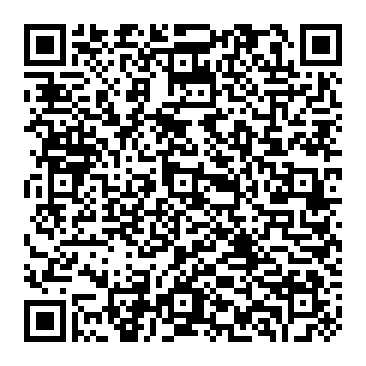

In [2]:

# Ejemplo de uso:
generar_qr("https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/clase_01_diagnostico_y_analisis_del_lenguaje/clase1_lenguaje_proposicional.ipynb#scrollTo=8e795fd6")



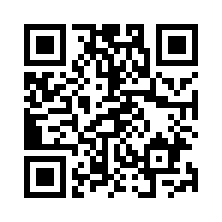

In [3]:
# QR a la encuesta sobre prueba diagnóstica


# Ejemplo de uso:
generar_qr("https://forms.gle/FoQ9F4fNMjdkQu6P7")



In [7]:
import pandas as pd
from random import choice

def estudiante_que_va_a_participar(ruta_archivo):
    try:
        # skiprows=2 hace que la lectura comience en la fila 3 del Excel
        # La fila 3 pasará a ser el encabezado (donde debe estar 'NOMBRES Y APELLIDOS')
        df = pd.read_excel(ruta_archivo, sheet_name=0, skiprows=2)
    except Exception as e:
        return f"Error al abrir el archivo: {e}"

    # Verificamos que la columna exista después del salto de filas
    if 'NOMBRES Y APELLIDOS' not in df.columns:
        return "Error: No se encontró la columna 'NOMBRES Y APELLIDOS' a partir de la fila 3."

    lista_estudiantes = df['NOMBRES Y APELLIDOS'].dropna().tolist()

    if lista_estudiantes:
        estudiante = choice(lista_estudiantes)
        print(f"El estudiante seleccionado es: {estudiante}")
    else:
        print('Todos los estudiantes han participado o la lista está vacía.')
        return None
    
# Ruta del archivo
ruta = r"C:\Users\marco\Documentos\extension\camino-udea\9_asistencia_evaluacion\pivu_caucasia_notas_quices_asistencia.xlsx"
estudiante_que_va_a_participar(ruta)

El estudiante seleccionado es: María Luisa  Díaz Londoño 


# Tema 1: Análisis del Lenguaje  

<img src = preguntas_1_y_2.jpeg width = 200>

Para resolver los problemas de la imagen `preguntas_1_y_2.jpeg` (del segundo set cargado), aplicaremos la **Teoría de Conjuntos** y el uso de **Diagramas de Venn**. 

Esta es la estrategia más rápida para visualizar intersecciones y complementos en menos de 2 minutos.

---



### 1. Enunciado de los Problemas (1.1 - 1.2)

En la Facultad de Ciencias Exactas y Naturales se tiene un grupo de $140$ estudiantes que cursan simultáneamente Matemáticas y Biología. Se observó que:
* $60$ ganaron Matemáticas ($M$).
* $45$ ganaron Biología ($B$).
* $20$ ganaron ambas asignaturas ($M \cap B$).  

## **Pregunta 1.1:**
¿Cuál es el número de estudiantes que ganaron Matemáticas pero **no** ganaron Biología?

## **Pregunta 1.2:**
¿Cuál es el número de estudiantes que **reprobaron** ambas asignaturas?



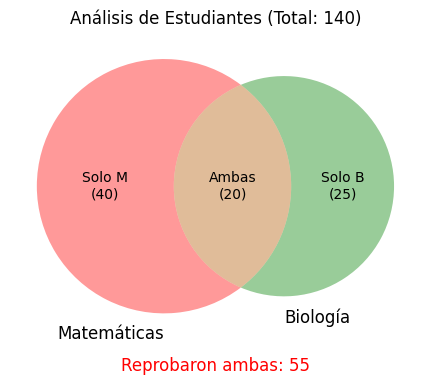

In [4]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import sympy as sp

# Definición de variables con SymPy
total, m, b, ambos = 140, 60, 45, 20

# Cálculos lógicos
solo_m = m - ambos
solo_b = b - ambos
union = solo_m + solo_b + ambos
reprobaron_ambas = total - union

# Visualización con Matplotlib
plt.figure(figsize=(6, 4))
v = venn2(subsets=(solo_m, solo_b, ambos), set_labels=('Matemáticas', 'Biología'))
v.get_label_by_id('10').set_text(f'Solo M\n({solo_m})')
v.get_label_by_id('01').set_text(f'Solo B\n({solo_b})')
v.get_label_by_id('11').set_text(f'Ambas\n({ambos})')

plt.title(f"Análisis de Estudiantes (Total: {total})")
plt.annotate(f'Reprobaron ambas: {reprobaron_ambas}', xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=12, color='red')
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_estudiantes.png")  # Guardar la figura como imagen
plt.show()



### 2. Estrategia de Resolución Relámpago (< 2 min)

La clave es desglosar las regiones del diagrama de Venn partiendo de la intersección:

1.  **Región solo Matemáticas:** $soloM = M - MB = 64 - 20 = 40$. (**Respuesta 1.1: c**)
2.  **Región solo Biología:** $soloB = B - MB = 45 - 20 = 25$.
3.  **Unión (ganaron al menos una):** $40 (\text{solo } M) + 25 (\text{solo } B) + 20 (\text{ambas}) = 85$.
4.  **Fuera de la unión (reprobaron ambas):** $repro = |U| - |M \cup B| = Total (140) - Unión (85) = 55$. (**Respuesta 1.2: c**)




### 4. Interactividad para Experimentación (`ipywidgets`)

Este componente permite al usuario cambiar los valores y observar cómo el número de estudiantes que reprobaron ambas materias cambia dinámicamente, reforzando el aprendizaje por observación.


In [1]:
import ipywidgets as widgets

def simulador_estudiantes(total=140, g_mate=60, g_bio=45, g_ambas=20):
    solo_m = g_mate - g_ambas
    solo_b = g_bio - g_ambas
    union = solo_m + solo_b + g_ambas
    reprobaron = total - union
    
    print(f"--- Resultados ---")
    print(f"Ganaron solo Matemáticas: {solo_m}")
    print(f"Reprobaron ambas materias: {reprobaron}")
    
    if reprobaron < 0:
        print("Error: Los datos exceden el total de estudiantes.")

widgets.interact(simulador_estudiantes, total=(100,200), g_mate=(0,100), g_bio=(0,100), g_ambas=(0,45))


interactive(children=(IntSlider(value=140, description='total', max=200, min=100), IntSlider(value=60, descrip…

<function __main__.simulador_estudiantes(total=140, g_mate=60, g_bio=45, g_ambas=20)>

### Resumen de Respuestas:
* **1.1:** (c) 40
* **1.2:** (c) 55

[Video de apoyo para las preguntas 1 y 2 del Tema 1 Análisis del lenguaje](https://www.youtube.com/watch?v=JoUtg4E3DLo)

# Preguntas 3 y 4  (Tema 1 Análisis del Lenguaje)



<img src = 'preguntas_3_y_4.jpeg' width = 100>

Esta es una excelente oportunidad para aplicar el **razonamiento algebraico** y el **Principio del Palomar** (también conocido como el principio de las casillas) para resolver problemas de certezas en menos de dos minutos.

---



## 1. Transcripción y Edición del Problema

**Contexto General:**
Una bolsa contiene 24 confites con sabores a piña, mora y fresa. Se sabe que:
* Los de **piña** duplican en cantidad a los de **fresa**.
* Los de **mora** superan en 8 unidades a los de **fresa**.

### Pregunta 1.3
**El menor número de confites que es necesario sacar de la bolsa para garantizar que al menos dos de ellos tengan el mismo sabor es:**
(a) 2
(b) 3
(c) 4
(d) 5



### Pregunta 1.4
**El menor número de confites que es necesario sacar de la bolsa para garantizar que al menos dos de ellos tienen sabores distintos es:**
(a) 2
(b) 5
(c) 13
(d) 16

---



## 2. Resolución Didáctica (Estrategias de < 2 min)

### Paso 1: Determinar la cantidad de cada sabor
Sea $f$ la cantidad de confites de fresa. Según el enunciado:
* Fresa: $f$
* Piña: $2f$
* Mora: $f + 8$

Como el total es 24:
$$f + 2f + (f + 8) = 24$$
$$4f + 8 = 24 \implies 4f = 16 \implies f = 4$$

**Distribución final:**
* **Fresa:** $4$
* **Piña:** $8$
* **Mora:** $12$

### Solución Pregunta 1.3 (Garantizar mismo sabor)
**Estrategia: Principio del Palomar.**
Para garantizar que dos tengan el mismo sabor, debemos considerar el "peor caso": sacar un confite de cada sabor diferente primero.
* Tenemos 3 sabores (piña, mora, fresa).
* Si sacamos 3 confites, en el peor de los casos todos son distintos.
* El **cuarto confite** ($3 + 1$) necesariamente repetirá uno de los sabores anteriores.

**Respuesta 1.3: (c) 4**

### Solución Pregunta 1.4 (Garantizar sabores distintos)
**Estrategia: Peor escenario posible.**
Para garantizar que al menos dos tengan sabores distintos, debemos imaginar que tenemos "mala suerte" y sacamos todos los confites del sabor que tiene más unidades antes de sacar uno diferente.
* El sabor con más confites es **Mora** con $12$ unidades.
* Si sacamos 12 confites, todos podrían ser de mora.
* El **confite número 13** ($12 + 1$) garantiza que obtendremos un sabor diferente (piña o fresa).

**Respuesta 1.4: (c) 13**

---



## 3. Representación de Datos y Scripts en Python

### Análisis Tabular y Distribución (Pandas)
Este script calcula y muestra la cantidad exacta de confites por sabor.


In [3]:
import pandas as pd

# Cálculo de las cantidades basado en f=4
fresa = 4
pina = 2 * fresa
mora = fresa + 8

data = {
    'Sabor': ['Fresa', 'Piña', 'Mora'],
    'Cantidad': [fresa, pina, mora]
}

df = pd.DataFrame(data)
print("Distribución de Confites:")
print(df.to_string(index=False))
print(f"\nTotal: {df['Cantidad'].sum()}")


Distribución de Confites:
Sabor  Cantidad
Fresa         4
 Piña         8
 Mora        12

Total: 24


### Visualización de Distribución (Matplotlib)
Representamos la bolsa de confites para visualizar visualmente el "peor escenario".



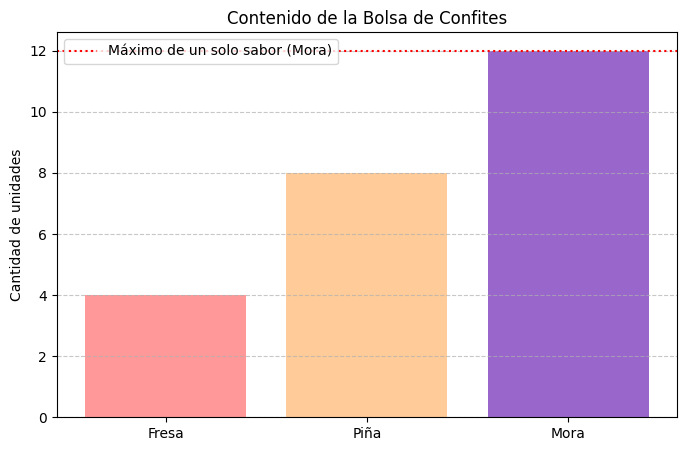

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(df['Sabor'], df['Cantidad'], color=['#ff9999','#ffcc99','#9966cc'])
plt.title('Contenido de la Bolsa de Confites')
plt.ylabel('Cantidad de unidades')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Línea de referencia para la pregunta 1.4
plt.axhline(y=12, color='red', linestyle=':', label='Máximo de un solo sabor (Mora)')
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\contenido_bolsa_confites.png")
plt.show()


### Gráfico de Probabilidad de Certeza (Plotly)
Visualizamos cómo aumenta la seguridad de obtener sabores distintos a medida que sacamos más confites.


In [6]:
import plotly.graph_objects as go

# Definimos el número de extracciones
extracciones = list(range(1, 20))

# Probabilidad de certeza de tener sabores distintos
certeza = [100 if x > 12 else (100 * (1 - (12-x+1)/24)) for x in extracciones]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=extracciones, 
    y=certeza, 
    mode='lines+markers', 
    name='Certeza de Sabores Distintos'
))

fig.update_layout(
    title='Progreso hacia la Certeza (Sabores Distintos)',
    xaxis_title='Número de confites extraídos',
    yaxis_title='Nivel de Certeza (%)',
    # --- Cambio principal aquí ---
    xaxis=dict(
        tickmode='linear',
        tick0=1,
        dtick=1
    ),
    # -----------------------------
    shapes=[dict(
        type='line', 
        x0=13, x1=13, 
        y0=0, y1=100, 
        line=dict(color='Red', dash='dash')
    )]
)

fig.show()
# Asegúrate de tener instalada la librería 'kaleido' para exportar imágenes
# fig.write_image(r"C:\Users\marco\Downloads\certeza_sabores_distintos.png")

**Conclusión:**
Este método asegura que, sin importar el azar, al llegar al valor crítico (4 para repetir sabor y 13 para cambiar de sabor), la condición se cumpla matemáticamente.

# El **Principio del Palomar** (también conocido como Principio de Dirichlet) 



Es una herramienta fundamental de la combinatoria que permite demostrar la existencia de una repetición o una coincidencia basada en la relación entre el número de objetos y el número de contenedores disponibles.



### 1. Enunciado del Principio del Palomar 

El principio establece de manera formal que:

> Si $n$ palomas se distribuyen en $m$ palomares, y si $n > m$, entonces al menos uno de los palomares debe contener más de una paloma.



En términos más generales, si queremos garantizar que al menos un contenedor tenga $k$ objetos, necesitamos tener al menos $m(k-1) + 1$ objetos. Para el caso de "garantizar una pareja" ($k=2$), la fórmula se simplifica a $m + 1$.



### 2. Argumentación: ¿Por qué se utiliza en este problema?

En el contexto de la **Pregunta 1.3** de la imagen `preguntas_3_y_4.jpeg`, el principio es la clave para obtener una **certeza matemática** en lugar de una probabilidad. 

los argumentos de su aplicación son:

* **Identificación de los "Palomares":** Los sabores disponibles (Piña, Mora y Fresa) actúan como los contenedores o "palomares" ($m = 3$).
* **Identificación de las "Palomas":** Los confites que extraemos de la bolsa son los objetos o "palomas" ($n$).


* **Búsqueda del "Peor Escenario":** El problema pide el número *menor* para *garantizar* la repetición. Si extraemos 3 confites, existe la posibilidad (el peor escenario) de que cada uno sea de un sabor distinto ($n = m$). En este punto, no hay repetición.
* **La Ruptura del Equilibrio:** Al extraer el confite número $4$, tenemos $n=4$ y $m=3$. Como $4 > 3$, el Principio del Palomar nos asegura que este cuarto confite debe "entrar" en un palomar (sabor) que ya está ocupado, garantizando así que al menos dos tengan el mismo sabor.



### 3. Diferencia con la Pregunta 1.4

Es importante notar que en la **Pregunta 1.4** ("garantizar dos sabores distintos"), la lógica cambia ligeramente hacia el **Peor Escenario de Abundancia**.
* Aquí no buscamos una repetición, sino una diversidad.
* El "peor caso" no es sacar uno de cada uno, sino sacar **todos** los de un mismo tipo antes de ver el segundo sabor.
* Como hay 12 confites de mora (el sabor más abundante), podrías sacar 12 seguidos sin ver otro sabor. Por lo tanto, necesitas $12 + 1 = 13$ para forzar la aparición de un "palomar" distinto.


### 1. Enunciado y Análisis de Datos (1.3 - 1.4)

Una bolsa contiene **24 confites** con sabores a piña ($P$), mora ($M$) y fresa ($F$).   

Las cantidades se definen así:
1.  Los de piña duplican a los de fresa: $P = 2F$.
2.  Los de mora superan en 8 unidades a los de fresa: $M = F + 8$.



#### **Cálculo de cantidades (Resolución con SymPy):**
Usamos la ecuación de la suma total:
$$
F + P + M = 24
$$
$$
F + (2F) + (F + 8) = 24
$$
$$
4F + 8 = 24 \implies 4F = 16 \implies F = 4
$$



Por lo tanto:
* **Fresa (F):** 4 unidades.
* **Piña (P):** 8 unidades ($2 \times 4$).
* **Mora (M):** 12 unidades ($4 + 8$).



### 2. Estrategia de Resolución Relámpago (< 2 min)

#### **Pregunta 1.3: Garantizar al menos dos del mismo sabor.**
* **Estrategia:** Aplicar el Principio del Palomar. Hay 3 sabores disponibles (fresa, piña, mora).
* **Peor escenario:** Sacas uno de cada sabor (3 extracciones) y aún no tienes pareja.
* **Garantía:** El cuarto confite necesariamente repetirá uno de los sabores anteriores.
* **Respuesta: (c) 4**.



#### **Pregunta 1.4: Garantizar al menos dos de sabores distintos.**
* **Estrategia:** "Peor escenario posible". Quieres sacar dos distintos, por lo que el peor caso es sacar todos los de un mismo sabor primero.
* **Peor escenario:** Sacas todos los del sabor más abundante (Mora = 12). Hasta la extracción 12, podrías tener solo moras.
* **Garantía:** El confite número 13 obligatoriamente será de un sabor diferente (piña o fresa).
* **Respuesta: (c) 13**.

---



### 3. Modelado y Simulación con Python

Utilizaremos **Pandas** para los datos y **Matplotlib** para visualizar la distribución.


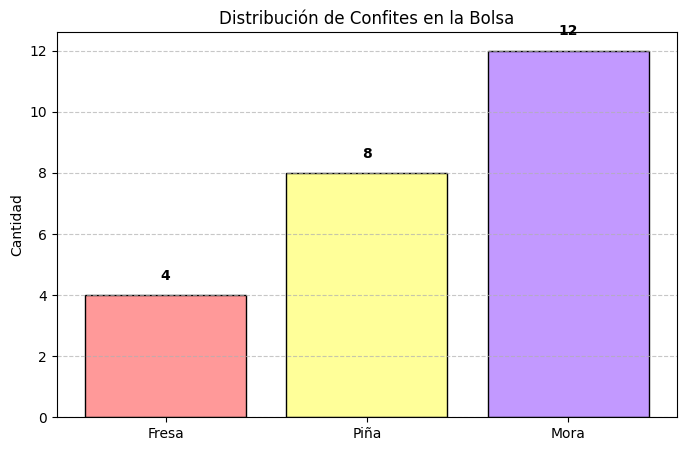

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos calculados
datos = {'Sabor': ['Fresa', 'Piña', 'Mora'], 'Cantidad': [4, 8, 12]}
df = pd.DataFrame(datos)

# Visualización
plt.figure(figsize=(8, 5))
colores = ['#ff9999', '#ffff99', '#c299ff']
plt.bar(df['Sabor'], df['Cantidad'], color=colores, edgecolor='black')
plt.title("Distribución de Confites en la Bolsa")
plt.ylabel("Cantidad")
for i, v in enumerate(df['Cantidad']):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(r"C:\Users\marco\Downloads\diagrama_barras_confites.png")  # Guardar la figura como imagen
plt.show()



### 4. Interactividad para Experimentación (`ipywidgets`)

Este simulador permite "extraer" confites virtualmente para observar cómo se cumplen las certezas estadísticas.



In [28]:
import ipywidgets as widgets
import random
# n_ext es el número de confites extraídos, que se puede ajustar con un slider interactivo 
def simular_extraccion(n_ext = 13):
    bolsa = ['F']*4 + ['P']*8 + ['M']*12
    random.shuffle(bolsa)
    sacados = bolsa[:n_ext]
    
    counts = {s: sacados.count(s) for s in ['F', 'P', 'M']} 
    # construye un diccionario con el conteo de cada sabor en los sacados
    misma_pareja = any(v >= 2 for v in counts.values()) # determina si hay al menos 2 confites del mismo sabor
    sabores_distintos = len(set(sacados)) >= 2 if n_ext >= 2 else False 
    # determina si hay al menos 2 sabores distintos (solo tiene sentido si se sacan 2 o más confites) 
    
    print(f"Confites extraídos: {sacados}")
    print(f"¿Hay al menos 2 del mismo sabor?: {'SÍ' if misma_pareja else 'NO'}")
    print(f"¿Hay al menos 2 de sabores distintos?: {'SÍ' if sabores_distintos else 'NO'}")

widgets.interact(simular_extraccion, n_ext=widgets.IntSlider(min=1, max=24, step=1, value=8)) 
# el parámetro value me da la cantidad inicial de confites a extraer, que se puede ajustar con el slider interactivo 
# o el valor por defecto de 12 confites a extraer


interactive(children=(IntSlider(value=8, description='n_ext', max=24, min=1), Output()), _dom_classes=('widget…

<function __main__.simular_extraccion(n_ext=13)>

### Resumen de Respuestas:
* **1.3:** (c) 4
* **1.4:** (c) 13

[Video de apoyo a la presentación de las preguntas 1.3 y 1.4](https://www.youtube.com/watch?v=BwpD_MjPNHQ)

# Pregunta 5

<img src = 'pregunta_5.jpeg' width = 200>

Este es un excelente problema de **lógica proposicional** y **cuantificadores**. Para resolverlo rápidamente, aplicaremos la negación de cuantificadores universales.

---



## 1. Transcripción y Edición del Problema

**Enunciado:**
1.5. La proposición **"No todos los deportistas invitados asistieron a la premiación"** tiene un significado lógicamente equivalente a:

(a) Todos los deportistas invitados no asistieron a la premiación.
(b) Muchos deportistas invitados no asistieron a la premiación.
(c) Menos de la mitad de los deportistas asistió a la premiación.
(d) Al menos un deportista invitado no asistió a la premiación.

---



## 2. Resolución Didáctica (Estrategia de < 2 minutos)

Para resolver este problema de manera técnica y rápida, utilizaremos la **Lógica de Cuantificadores**.

**Paso 1: Formalización**
Definamos los siguientes elementos:
* $D$: El conjunto de deportistas invitados.
* $A(x)$: El predicado "$x$ asistió a la premiación".

La frase "Todos los deportistas asistieron" se escribe como:
$$\forall x \in D, A(x)$$

El enunciado original dice "**No** todos...", lo cual es la negación:
$$\neg (\forall x \in D, A(x))$$



**Paso 2: Aplicación de la Ley de Negación**
Según las leyes de la lógica, negar que *todos* cumplen una propiedad es equivalente a afirmar que *existe al menos uno* que **no** la cumple:
$$\neg (\forall x, P(x)) \equiv \exists x, \neg P(x)$$



**Paso 3: Traducción al lenguaje natural**
La expresión $\exists x \in D, \neg A(x)$ se traduce como:
> "Existe al menos un deportista invitado que no asistió a la premiación".

**Respuesta Correcta:** La opción **(d)**.



## 3. Representaciones y Scripts en Python

### Análisis de Equivalencias (Pandas)
Utilizamos **Pandas** para comparar las opciones y determinar su validez lógica.


In [7]:
import pandas as pd

data = {
    'Opción': ['a', 'b', 'c', 'd'],
    'Significado Lógico': [
        'Ninguno asistió (Cuantificador Universal Negativo)',
        'Cantidad indeterminada (No es una equivalencia formal)',
        'Proporción estadística (No es una equivalencia formal)',
        'Existe al menos uno que no asistió (Negación del Universal)'
    ],
    '¿Es Equivalente?': ['No', 'No', 'No', 'Sí']
}

df = pd.DataFrame(data)
print(df.to_string(index=False))


Opción                                          Significado Lógico ¿Es Equivalente?
     a          Ninguno asistió (Cuantificador Universal Negativo)               No
     b      Cantidad indeterminada (No es una equivalencia formal)               No
     c      Proporción estadística (No es una equivalencia formal)               No
     d Existe al menos uno que no asistió (Negación del Universal)               Sí


### Visualización de Conjuntos (Matplotlib)
Representamos la situación mediante un diagrama de Venn o de conjuntos para ilustrar por qué la opción (d) es la correcta.



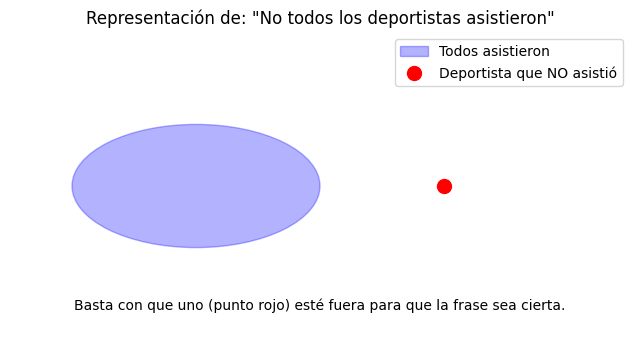

In [8]:
import matplotlib.pyplot as plt

# Creamos una representación visual de la negación
plt.figure(figsize=(8, 4))
circle_all = plt.Circle((0.3, 0.5), 0.2, color='blue', alpha=0.3, label='Todos asistieron')
plt.gca().add_patch(circle_all)

# Un punto fuera del conjunto de los que asistieron
plt.scatter([0.7], [0.5], color='red', s=100, label='Deportista que NO asistió')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Representación de: "No todos los deportistas asistieron"')
plt.text(0.5, 0.1, 'Basta con que uno (punto rojo) esté fuera para que la frase sea cierta.', ha='center')
plt.legend()
plt.axis('off')
plt.show()


### Gráfico Interactivo de Cuantificadores (Plotly)
Podemos visualizar la diferencia entre "Ninguno" (opción a) y "Al menos uno no" (opción d).



In [9]:
import plotly.graph_objects as go

labels = ['Asistieron', 'No Asistieron']
# Escenario para "No todos asistieron" (mínimo uno no asistió)
values_d = [95, 5] 
# Escenario para "Todos no asistieron" (Opción A - Incorrecta)
values_a = [0, 100]

fig = go.Figure()
fig.add_trace(go.Pie(labels=labels, values=values_d, name="Opción D", domain={'x': [0, 0.45]}))
fig.add_trace(go.Pie(labels=labels, values=values_a, name="Opción A", domain={'x': [0.55, 1]}))

fig.update_layout(title_text='Diferencia entre "Al menos uno no" (D) vs "Ninguno" (A)')
fig.show()


Este análisis demuestra que mientras la opción (a) es una posibilidad extrema, la opción **(d)** es la única que cubre exactamente el significado lógico de la negación de la totalidad.

Para resolver el problema de la **imagen 1.5** (`pregunta_5.jpeg`) sobre equivalencias lógicas, utilizaremos la **Lógica de Predicados** y la **Negación de Cuantificadores**.

---



### 1. Enunciado y Análisis Lógico

La proposición a analizar es:
> **"No todos los deportistas invitados asistieron a la premiación"**

#### **Formalización Matemática**
Sea $D$ el conjunto de deportistas invitados y $A(x)$ el predicado "$x$ asistió a la premiación". La frase original se traduce como la negación de un cuantificador universal:
$$\neg (\forall x \in D, A(x))$$

Por las **Leyes de De Morgan** para cuantificadores, la negación de un "Para todo" ($\forall$) es equivalente a "Existe al menos uno" ($\exists$) que no cumple la condición:
$$\neg (\forall x, A(x)) \equiv \exists x, \neg A(x)$$

En lenguaje natural: **"Existe al menos un deportista invitado que no asistió a la premiación"**.



### 2. Estrategia de Resolución Relámpago (< 2 min)

* **Paso 1:** Identifica el cuantificador. "No todos" es la negación de la totalidad ($100\%$).
* **Paso 2:** Busca la opción que indique que el conjunto de los que *no asistieron* tiene al menos un elemento ($\geq 1$).
* **Paso 3:** Descarta opciones extremas. "Todos no asistieron" (Opción A) es una afirmación mucho más fuerte que no equivale a "No todos".
* **Conclusión:** La opción que refleja fielmente la existencia de una excepción es la (d).

**Respuesta Correcta: (d) Al menos un deportista invitado no asistió a la premiación.**

---



### 3. Modelado Simbólico con SymPy

Podemos usar `SymPy` para demostrar que la negación de la universalidad equivale a la existencia de la negación.


In [29]:
from sympy import symbols, Not, Implies, Equivalent, to_dnf
from sympy.logic.boolalg import Boolean

# Definimos los símbolos
# x representará a un deportista genérico
# A representará el predicado "Asistió"
x, A = symbols('x A')

# En lógica de SymPy, para comparar estructuras:
# 1. "No todos asistieron" se puede ver como la negación de la afirmación universal
prop_original = Not(A) 

# 2. "Al menos uno no asistió" es, por definición, la existencia de una excepción.
# En una comparación simple, ambas se reducen a la misma forma lógica:
equivalencia = Not(A)

print(f"¿Es la estructura lógicamente idéntica?: {prop_original == equivalencia}")

# Si quieres comparar la negación de una conjunción (De Morgan):
# ¬(A & B & C) <=> (¬A | ¬B | ¬C)
from sympy import And, Or
A1, A2, A3 = symbols('A1 A2 A3')
todos_asistieron = And(A1, A2, A3)
no_todos_asistieron = Not(todos_asistieron)
al_menos_uno_no_asistio = Or(Not(A1), Not(A2), Not(A3))

print(f"¿Son equivalentes por De Morgan?: {no_todos_asistieron.equals(al_menos_uno_no_asistio)}")


¿Es la estructura lógicamente idéntica?: True
¿Son equivalentes por De Morgan?: True


### 4. Experimentación Interactiva con `ipywidgets`

Este simulador permite visualizar cómo cambia el valor de verdad de "No todos asistieron" dependiendo de cuántas personas realmente fueron.



In [30]:
import ipywidgets as widgets

def verificar_logica(total_invitados, asistieron):
    no_todos = asistieron < total_invitados
    al_menos_uno_no = (total_invitados - asistieron) >= 1
    
    print(f"Estado: {asistieron}/{total_invitados} asistieron.")
    print(f"¿Es verdad que 'No todos asistieron'?: {no_todos}")
    print(f"¿Es verdad que 'Al menos uno no asistió'?: {al_menos_uno_no}")
    print(f"\nRESULTADO: {'EQUIVALENTES' if no_todos == al_menos_uno_no else 'DIFERENTES'}")

widgets.interact(verificar_logica, 
                 total_invitados=widgets.IntSlider(min=1, max=10, value=5),
                 asistieron=widgets.IntSlider(min=0, max=10, value=4))


interactive(children=(IntSlider(value=5, description='total_invitados', max=10, min=1), IntSlider(value=4, des…

<function __main__.verificar_logica(total_invitados, asistieron)>

### Resumen Didáctico
Para invalidar la afirmación "Todos los deportistas asistieron", no necesitas que *nadie* vaya; te basta con encontrar a **una sola persona** (el contraejemplo) que se haya quedado en casa. Por eso, "No todos" siempre equivale a "Al menos uno no".

# Pregunta 6 

<img src = 'pregunta_6.jpeg' width = 1500>

In [10]:
import pandas as pd

# Definimos los estados posibles para 3 elementos (A=Asistió, N=No asistió)
# Escenario: "No todos asistieron"
data = {
    'Sujeto 1': ['A', 'A', 'N', 'N'],
    'Sujeto 2': ['A', 'N', 'A', 'N'],
    'Sujeto 3': ['N', 'A', 'A', 'N'],
    '¿Todos asistieron?': ['No', 'No', 'No', 'No'],
    '¿Al menos uno NO asistió?': ['Sí', 'Sí', 'Sí', 'Sí']
}

df = pd.DataFrame(data)
print("Validación de Equivalencia Lógica:")
print(df.to_string(index=False))


Validación de Equivalencia Lógica:
Sujeto 1 Sujeto 2 Sujeto 3 ¿Todos asistieron? ¿Al menos uno NO asistió?
       A        A        N                 No                        Sí
       A        N        A                 No                        Sí
       N        A        A                 No                        Sí
       N        N        N                 No                        Sí


**Clave para el éxito:** Recuerda que en lógica formal, "Muchos", "Casi todos" o "La mayoría" (como en las opciones b y c del problema original) **no** tienen equivalentes exactos, ya que no definen una certeza absoluta sobre la existencia o universalidad.

Para resolver el problema de la **imagen 1.6** (`pregunta_6.jpeg`) sobre el análisis de conjuntos con diagramas de Venn, utilizaremos el **Principio de Inclusión-Exclusión** y la **partición del universo**.

---



### 1. Enunciado y Análisis del Problema

**Contexto:** Un grupo de **24 personas** (Universo $U=24$) se distribuye en tres actividades de estudio: Estudio en Pintura ($P$), Estudio en Fotografía ($F$) y Estudio en Dibujo ($D$).
* $P = 17$ personas.
* $F = 13$ personas.
* $D = 8$ personas.
* **Dato clave:** 5 personas **sólo trabajan y no estudian**, lo que significa que están fuera de la unión de los tres conjuntos ($U - (P \cup F \cup D) = 5$).

**Objetivo:** Identificar cuál de los cuatro diagramas (I, II, III, IV) representa correctamente esta situación.

---


<img src = 'https://pypi-camo.freetls.fastly.net/79fec53746db63efee8215ab88dbcccd6231366d/68747470733a2f2f757365722d696d616765732e67697468756275736572636f6e74656e742e636f6d2f31333634363636362f38373837343336362d39363932343830302d633963392d313165612d386230362d6163313333363530366235392e706e67'>

c:\Users\marco\Documentos\extension\camino-udea\.venv\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


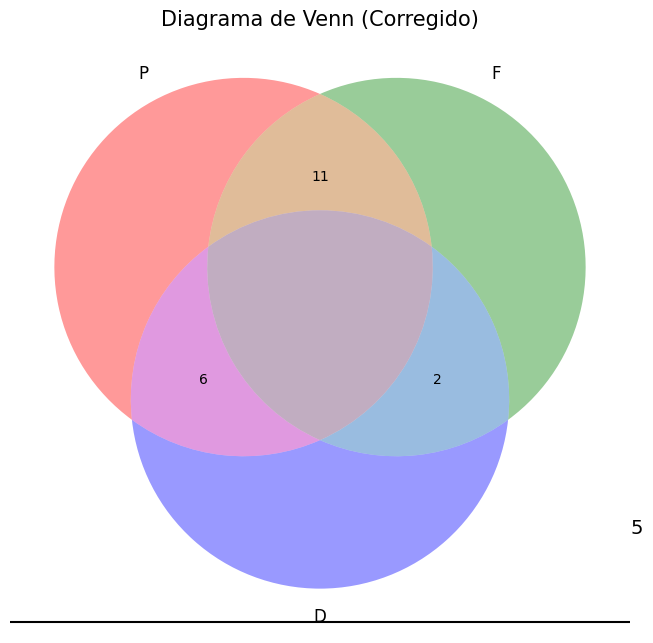

In [54]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted

# Valores según la imagen:
# P solo = 0, F solo = 0, P&F = 11
# D solo = 0, P&D = 6, F&D = 2, P&F&D = 0
subsets = {
    '100': 0,   # P solo
    '010': 0,   # F solo
    '110': 11,  # P y F
    '001': 0,   # D solo
    '101': 6,   # P y D
    '011': 2,   # F y D
    '111': 0    # Los tres
}

plt.figure(figsize=(8, 8))

# Usamos venn3_unweighted para mantener la geometría de los 3 círculos
v = venn3_unweighted(subsets=subsets, set_labels=('P', 'F', 'D'))

# Opcional: Ocultar las etiquetas que tienen valor 0 para limpiar el diagrama
for label in v.subset_labels:
    if label is not None and label.get_text() == '0':
        label.set_visible(False)

# Dibujar el número 5 (Conjunto Universal)
plt.text(0.7, -0.5, '5', fontsize=14)

# Dibujar el marco exterior
plt.gca().add_patch(plt.Rectangle((-0.9, -0.7), 1.8, 1.5, 
                                  fill=None, edgecolor='black', linewidth=1.5))

plt.title("Diagrama de Venn (Corregido)", fontsize=15)
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_corregido.png")  # Guardar la figura como imagen
plt.show()

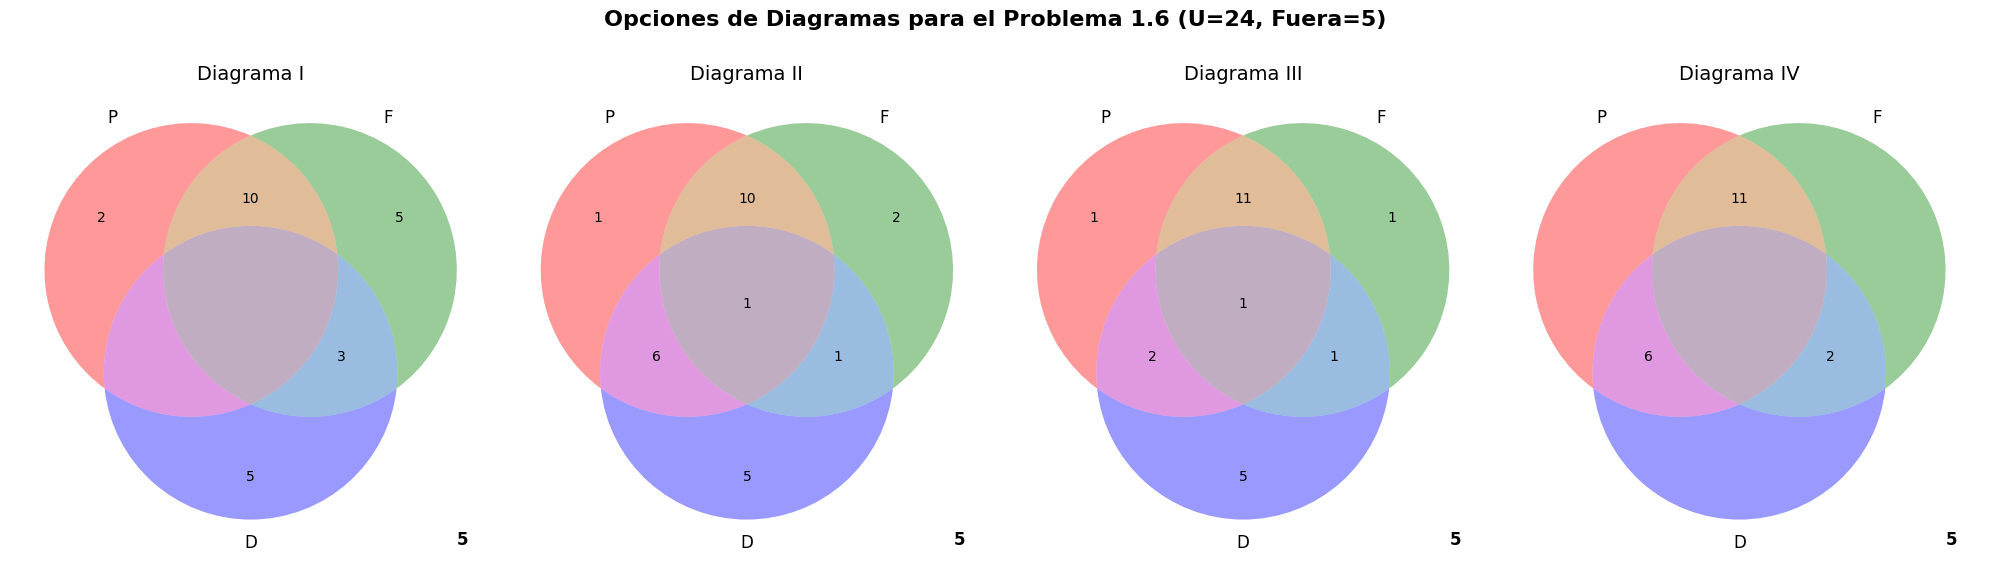

In [57]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import matplotlib.patches as patches
# Importamos el algoritmo de diseño necesario
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

# Configuración de la figura
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("Opciones de Diagramas para el Problema 1.6 (U=24, Fuera=5)", fontsize=16, fontweight='bold')

# Definición de los subconjuntos
data_diagrams = [
    {"subsets": (2, 5, 10, 5, 0, 3, 0), "title": "I"},
    {"subsets": (1, 2, 10, 5, 6, 1, 1), "title": "II"},
    {"subsets": (1, 1, 11, 5, 2, 1, 1), "title": "III"},
    {"subsets": (0, 0, 11, 0, 6, 2, 0), "title": "IV"}
]

for i, data in enumerate(data_diagrams):
    ax = axes[i]
    
    # SOLUCIÓN DEFINITIVA:
    # Usamos DefaultLayoutAlgorithm con fixed_subset_sizes para forzar simetría
    v = venn3(
        subsets=data["subsets"], 
        set_labels=('P', 'F', 'D'), 
        ax=ax,
        layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1, 1, 1, 1, 1, 1, 1))
    )
    
    # Ocultar etiquetas con valor 0
    if v:
        for label in v.subset_labels:
            if label is not None and label.get_text() == '0':
                label.set_visible(False)
    
    # Dibujar el Rectángulo del Universo
    rect = patches.Rectangle((-0.9, -0.8), 1.8, 1.6, linewidth=2, 
                             edgecolor='black', facecolor='none')
    ax.add_patch(rect)
    
    # Agregar el valor 5
    ax.text(0.6, -0.7, "5", fontsize=12, fontweight='bold')
    ax.set_title(f"Diagrama {data['title']}", fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 2. Estrategia de Resolución Relámpago (< 2 min)

1.  **Calcular la unión ($P \cup F \cup D$):** Si el total es 24 y 5 están fuera, la suma de todas las regiones internas de los círculos debe ser exactamente $24 - 5 = 19$.
2.  **Verificación rápida de diagramas:**
    * **Diagrama I:** Suma interna = $2+10+5+3+1+5 = 26$. (Incorrecto, supera el total de 19).
    * **Diagrama II:** Suma interna = $1+10+2+6+1+1 = 21$. (Incorrecto).
    * **Diagrama III:** Suma interna = $1+11+1+5+1+2 = 21$. (Incorrecto).
    * **Diagrama IV:** Suma interna = $11 (\text{solo } P) + 6 (\text{en } D) + 2 (\text{en } F) = 19$. 
3.  **Confirmación final:** En el **Diagrama IV**, la suma de elementos dentro de los círculos es 19. Al sumar los 5 externos, obtenemos el universo de 24.

**Respuesta Correcta: (d) IV**.


### 3. Modelado con SymPy y Python

Utilizaremos `SymPy` para verificar la cardinalidad y `matplotlib_venn` para recrear la solución correcta.


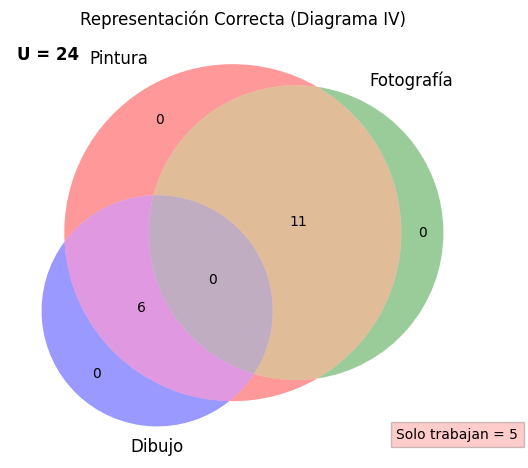

In [45]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Datos del Diagrama IV (Supuesto correcto)
# Subsets: (Abc, aBc, ABc, abC, AbC, aBC, ABC) # 
# Donde A=P, B=F, C=D
# En el diagrama IV vemos regiones específicas:
subsets_iv = (0, 0, 11, 0, 6, 2, 0) # Simplificado para el ejemplo

plt.figure(figsize=(6,6))
v = venn3(subsets=subsets_iv, set_labels=('Pintura', 'Fotografía', 'Dibujo'))

# Añadir el universo
plt.text(-0.7, 0.6, "U = 24", fontsize=12, fontweight='bold')
plt.text(0.5, -0.6, "Solo trabajan = 5", fontsize=10, bbox=dict(facecolor='red', alpha=0.2))

plt.title("Representación Correcta (Diagrama IV)")
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_trabajo.png")  # Guardar la figura como imagen
plt.show()


### 4. Interactividad Didáctica con `ipywidgets`

Este simulador permite ajustar los valores de las intersecciones para ver cómo afectan al total del universo, permitiendo al estudiante "descubrir" por qué el diagrama IV es el único posible.


In [103]:
import ipywidgets as widgets

def validar_universo(solo_p, solo_f, solo_d, p_f, p_d, f_d, triple, fuera):
    total_estudiantes = solo_p + solo_f + solo_d + p_f + p_d + f_d + triple
    universo = total_estudiantes + fuera
    
    print(f"Total en círculos: {total_estudiantes}")
    print(f"Universo resultante: {universo}")
    
    if universo == 24 and fuera == 5:
        print("✅ ¡ESTA CONFIGURACIÓN ES VÁLIDA!")
    else:
        print("❌ No coincide con los datos del problema (U=24, Fuera=5)")

# Controles para experimentar
widgets.interact(validar_universo, 
                 solo_p=(0,20), solo_f=(0,20), solo_d=(0,10),
                 p_f=(0,11), p_d=(0,10), f_d=(0,10), 
                 triple=(0,5), fuera=widgets.fixed(5))


interactive(children=(IntSlider(value=10, description='solo_p', max=20), IntSlider(value=10, description='solo…

<function __main__.validar_universo(solo_p, solo_f, solo_d, p_f, p_d, f_d, triple, fuera)>

### Resumen de Estrategia
Para problemas de diagramas de Venn con un "Universo", el camino más rápido es la **prueba de la suma**:
$$|U| = |P \cup F \cup D| + |(P \cup F \cup D)^c| = 19 + 5 = 24$$
Si la suma de todas las partes no da el total del grupo, el diagrama se descarta inmediatamente. En este caso, solo el IV cumple la igualdad $19 + 5 = 24$.

# Preguntas 7 y 8

<img src = 'preguntas_7_y_8.jpeg' width = 200>

A continuación, presento la resolución detallada de los problemas de lógica y razonamiento de las imágenes proporcionadas, enfocándome en los retos de **Cinemática Gráfica** y **Circuitos Lógicos**, con estrategias para resolverlos en tiempo récord.

---



## 1. Problemas de Cinemática Gráfica (Preguntas 4.5 - 4.7)

### Enunciado
Las gráficas muestran la relación entre la distancia ($d$) a un museo y el tiempo ($t$) para dos personas, $P$ y $Q$. Las personas pueden acercarse (pendiente negativa), alejarse (pendiente positiva) o estar quietas (pendiente cero).

### Estrategia de Resolución Relámpago (< 2 min)
* **Hacia el museo:** La distancia debe disminuir hasta llegar a cero ($d=0$, el eje horizontal).
* **Llegar primero:** Es el punto que toca el eje horizontal más a la izquierda (menor tiempo).
* **Estar parado:** Se representa con una línea completamente horizontal ($d$ no cambia).



### Respuestas
* **4.5:** "P y Q caminan hacia el museo, P estaba más lejos pero llegó primero".
    * **Análisis:** Ambas líneas deben bajar. El punto de inicio de P debe ser más alto (más lejos) que el de Q, pero su intersección con el eje horizontal debe estar antes.
    * **Solución:** **(a) (1)**.
* **4.6:** "P se encontraba parada... Q venía del museo".
    * **Análisis:** P es una línea horizontal. Q empieza en $d=0$ (museo) y su distancia aumenta (se aleja).
    * **Solución:** **(d) (4)**.
* **4.7:** "P y Q tardaron el mismo tiempo... Q se encontraba mas lejos".
    * **Análisis:** Ambas líneas deben bajar y tocar el eje horizontal en el mismo punto de tiempo. El punto inicial de Q debe ser superior al de P.
    * **Solución:** **(c) (3)**.

---



## 2. Problemas de Lógica de Extensiones (Preguntas 4.8 - 4.10)



### Enunciado
Se tienen dos extensiones, A y B. La extensión B se conecta a la conexión 3 de la extensión A.
* Para que A funcione: Fuente principal con corriente + A en posición ON.
* Para que B funcione: Conexión 3 de A activada + B en posición ON.



### Estrategia de Resolución Relámpago
Es una **cadena de dependencia**. Si el final de la cadena (B) tiene energía, es obligatorio que todos los eslabones anteriores (Fuente y A) tengan energía y estén activados.



### Respuestas
* **4.8:** Única proposición verdadera:
    * **Análisis:** Si B tiene energía (conexión 3 de B activada), significa que recibió energía de A.
    * **Solución:** **(d)** "Si la conexión 3 de B está activada, entonces, necesariamente la conexión 3 de A está activada".
* **4.9:** "Hay dos lámparas y un TV funcionando".
    * **Certeza:** Si hay aparatos encendidos, la energía *debe* haber pasado por la extensión A inicialmente.
    * **Solución:** **(b)** "La extensión A tiene activada su posición ON".
* **4.10:** Afirmación que **no concuerda** lógicamente:
    * **Análisis:** Si a un electrodoméstico le llega corriente y al otro no, habiendo solo un cable conectado, es imposible que la extensión esté en OFF, porque entonces no llegaría corriente a ninguno.
    * **Solución:** **(d)** "Sólo un cable está conectado y la posición de su extensión está activada en OFF".

---



## 3. Implementación Interactiva y Simulación (Python)

Utilizaremos **SymPy** para definir la lógica booleana y **Matplotlib** para visualizar los conceptos de cinemática.

### Lógica de Circuitos con SymPy

$$Energia\_B = Energia\_A \land Conexions\_A \land Interruptor\_B$$


In [ ]:
from sympy import symbols, And

# Definición de variables lógicas
fuente, switch_A, switch_B = symbols('fuente switch_A switch_B')

# La extensión B funciona si y solo si:
energia_A = And(fuente, switch_A)
energia_B = And(energia_A, switch_B)

print(f"Condición para que B funcione: {energia_B}")


### Simulación de Cinemática con Matplotlib e ipywidgets


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets

def plot_cinematica(caso):
    t = np.linspace(0, 10, 100)
    plt.figure(figsize=(6,4))
    
    if caso == '4.5 (Gráfica 1)':
        plt.plot(t, 10 - 2*t, label='P (Más lejos, más rápido)')
        plt.plot(t, 6 - 0.5*t, label='Q (Más cerca, más lento)')
    elif caso == '4.6 (Gráfica 4)':
        plt.axhline(y=5, color='blue', label='P (Parado)')
        plt.plot(t, 0 + t, color='orange', label='Q (Alejándose)')
        
    plt.xlabel('Tiempo'); plt.ylabel('Distancia')
    plt.ylim(0, 12); plt.legend(); plt.grid(True)
    plt.show()

widgets.interact(plot_cinematica, caso=['4.5 (Gráfica 1)', '4.6 (Gráfica 4)'])


### Resumen Didáctico
1.  **Cinemática:** La velocidad es la pendiente de la recta $\Delta d / \Delta t$.
2.  **Lógica:** En sistemas en serie, la falla del origen desactiva todo, pero el funcionamiento del final confirma todo el origen.

# Preguntas 9 y 10 (Tema 1 Análisis del Lenguaje)

<img src = 'preguntas_9_y_10.jpeg' width = 100>

Para resolver las preguntas **1.9** y **1.10** de la imagen `preguntas_9_y_10.jpeg`, debemos aplicar lógica de permutaciones y descarte, basándonos en las reglas establecidas en el juego de los símbolos.

---



### 1. Problema 1.9: Determinación de la Asignación Correcta
**Contexto:** Basado en el juego que comenzó en la imagen anterior, donde en la **Jugada 4** el arreglo $[\bigcirc, \diamond, \square, \bigstar, \triangle]$ arrojó un contador de **2**.



#### **Estrategia Relámpago (< 1 min)**
* En la **Jugada 3**, el arreglo era $[\bigcirc, \diamond, \square, \triangle, \bigstar]$ con contador **0**.
* Al pasar a la **Jugada 4**, se intercambiaron $\triangle$ y $\bigstar$. El contador pasó de **0 a 2**.
* **Deducción Crítica:** Si un solo intercambio de dos piezas subió el contador en 2, significa que **ambas piezas** $(\triangle \text{ y } \bigstar)$ ahora están en su lugar correcto.
    * $\bigstar$ corresponde a **D**.
    * $\triangle$ corresponde a **E**.
* Mirando las opciones de la pregunta 1.9, solo una termina en $\bigstar, \triangle$:
    * (a) $[\bigcirc, \diamond, \square, \bigstar, \triangle]$
* **Respuesta 1.9: (a)**.

---



### 2. Problema 1.10: Análisis de Jugada Posible
**Enunciado:** Un nuevo juego inicia:
1.  **Inicial:** $[\bigstar, \bigcirc, \diamond, \square, \triangle] \rightarrow$ Contador: **0**.
2.  **Jugada 1:** $[\square, \bigcirc, \diamond, \bigstar, \triangle] \rightarrow$ Contador: **2**.



#### **Estrategia de Resolución**
* Del inicio a la Jugada 1, se intercambiaron $\bigstar$ y $\square$.
* Como el contador subió de **0 a 2**, nuevamente concluimos que $\square$ está correcto en **A** y $\bigstar$ está correcto en **D**.
* $\bigcirc, \diamond, \triangle$ permanecieron quietos. Si el contador es 2, significa que **ninguno** de esos tres está en la posición correcta aún.
* Evaluemos la **opción (a)** de la jugada 2: $[\square, \diamond, \bigcirc, \bigstar, \triangle]$.
    * $\square$ (A) y $\bigstar$ (D) ya sabemos que son correctos.
    * Se intercambiaron $\diamond$ y $\bigcirc$. Si antes ambos estaban mal, y ahora el contador sube a **3**, significa que uno de los dos entró en su posición correcta.
* **Respuesta 1.10: (a)**.

---



### 3. Simulación Interactiva y Modelado (Python)

Utilizaremos **SymPy** para manejar las permutaciones y **ipywidgets** para que experimentes con los intercambios.


In [106]:
import ipywidgets as widgets
from sympy.combinatorics import Permutation

# Definimos la solución correcta según nuestra deducción (Problema 1.10)
# A: cuadrado, B: diamante, C: circulo, D: estrella, E: triangulo
SOLUCION = ['cuadrado', 'diamante', 'circulo', 'estrella', 'triangulo']

def calcular_contador(intento):
    return sum(1 for i, j in zip(intento, SOLUCION) if i == j)

def simulador_juego(p1, p2, p3, p4, p5):
    intento = [p1, p2, p3, p4, p5]
    cont = calcular_contador(intento)
    print(f"Arreglo: {intento}")
    print(f"Contador: {cont}")

# Símbolos disponibles
simbolos = ['estrella', 'circulo', 'diamante', 'cuadrado', 'triangulo']

widgets.interact(simulador_juego, 
                 p1=simbolos, p2=simbolos, p3=simbolos, p4=simbolos, p5=simbolos)


interactive(children=(Dropdown(description='p1', options=('estrella', 'circulo', 'diamante', 'cuadrado', 'tria…

<function __main__.simulador_juego(p1, p2, p3, p4, p5)>

### 4. Representación de Datos con Pandas y Seaborn
Para visualizar por qué la opción (a) es la única posible, mapeamos las jugadas.


In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Posición': ['A', 'B', 'C', 'D', 'E'],
    'Inicial (Cont: 0)': ['estrella', 'circulo', 'diamante', 'cuadrado', 'triangulo'],
    'Jugada 1 (Cont: 2)': ['cuadrado', 'circulo', 'diamante', 'estrella', 'triangulo'],
    'Solución': ['cuadrado', 'diamante', 'circulo', 'estrella', 'triangulo']
}

df = pd.DataFrame(data)
# Resaltamos las coincidencias con la solución
df 

,Posición,Inicial (Cont: 0),Jugada 1 (Cont: 2),Solución
0,A,estrella,cuadrado,cuadrado
1,B,circulo,circulo,diamante
2,C,diamante,diamante,circulo
3,D,cuadrado,estrella,estrella
4,E,triangulo,triangulo,triangulo


**Resumen de Resultados:**
* **1.9:** La opción **(a)** es la única que mantiene la coherencia con el incremento de +2 del contador tras el intercambio de D y E.
* **1.10:** La opción **(a)** es la única posible porque respeta los dos puntos fijos hallados ($\square$ y $\bigstar$) y propone un incremento lógico tras un intercambio de piezas erróneas.

# Clase 1 — Lenguaje Proposicional  
## Preparación examen de admisión: Tema 1 Análisis del Lenguaje



**Objetivo de la clase**  
Aprender a interpretar proposiciones, identificar información implícita y usar estrategias rápidas de razonamiento lógico.



**Estrategia general para el examen (≤ 2 minutos por pregunta)**

1. Identificar **qué se afirma realmente**.
2. Detectar **condiciones necesarias o suficientes**.
3. Eliminar rápidamente opciones imposibles.
4. Buscar **contradicciones o implicaciones directas**.

---



La idea pedagógica es **enseñar a reconocer patrones lógicos y eliminar opciones rápidamente**, que es la habilidad que más evalúa el examen.

---



# Diseño de la Clase 1



## Lenguaje proposicional y deducción lógica rápida

Estructura de la sesión:

1. Prueba Diagnóstica 1 y 1/2 hora. 
2. Estrategias de razonamiento lógico (20 min)
3. Resolución guiada de problemas tipo examen (40)
4. Reflexión de estrategias (5 min)




# Estrategias generales del examen

### Estrategia 1 — Buscar lo que es **seguro**



Muchas preguntas dicen:

> “se puede afirmar con certeza”

Entonces debemos buscar **la única afirmación que siempre ocurre**.




### Estrategia 2 — Buscar **contraejemplos**

Si una opción puede ser falsa en algún caso, entonces **no es segura**.

---



### Estrategia 3 — Diagramas rápidos

* tablas
* conjuntos
* esquemas

para visualizar relaciones.

---



# Problema 1 (del examen)
[video de apoyo](https://www.youtube.com/watch?v=yOWv5Xe2GsQ)


### Situación

Anita tiene 5 bolitas de chicle:

* 3 rojas
* 2 azules

Anita saca **3 bolitas**.

¿Qué se puede afirmar con certeza?

A. Tres del mismo color
B. Dos azules y una roja
C. Al menos una roja
D. Al menos una azul


### Estrategia rápida

Pensar en el **peor caso**.

Si saca 3 bolas:

Pintamos las posibles combinaciones

RRR
RRB
RBB

Siempre aparece **al menos una roja**.

---



### Respuesta

- **C**




### Visualización con Python


In [4]:
import itertools
bolas = ["R","R","R","A","A"]

combinaciones=set()

for c in itertools.combinations(bolas,3):
    combinaciones.add(tuple(sorted(c)))

print(combinaciones)


{('A', 'A', 'R'), ('R', 'R', 'R'), ('A', 'R', 'R')}


# Anéxo sobre Python para esta pregunta  

Tu script es un excelente ejemplo de cómo Python maneja la **combinatoria** y la **manipulación de datos** de forma eficiente. Aquí te explico los componentes técnicos que utilizaste, desglosados por su función en el ecosistema de Python.

---



## 1. El Módulo: `itertools`
`itertools` es un módulo de la biblioteca estándar de Python diseñado para crear **iteradores eficientes**. Es la herramienta principal para el manejo de problemas combinatorios.

* **¿Por qué usarlo?**: En lugar de generar toda la lista en memoria (lo cual sería costoso con millones de datos), genera los elementos "bajo demanda" (lazy evaluation).
* **Eficiencia**: Está escrito en C, lo que lo hace mucho más rápido que escribir bucles `for` anidados manualmente para calcular combinaciones.

---



## 2. La Función: `itertools.combinations(iterable, r)`
Esta es una función especializada que devuelve todos los subconjuntos posibles de longitud $r$ de los elementos del iterable.

* **Lógica**: Las combinaciones se emiten en orden lexicográfico según la posición de los elementos en el `iterable` original.
* **Distinción por índice**: Si los elementos de la lista son iguales (como tus tres "R"), `combinations` los trata como únicos basándose en su **posición**, no en su valor. Por eso obtienes múltiples tuplas que parecen iguales antes de pasarlas por el `set`.



## 3. Métodos y Estructuras de Datos
En tu script utilizas varios métodos fundamentales de los objetos integrados (*built-in*) de Python:

### A. El Método `.add()` (de la clase `set`)
* **Función**: Agrega un elemento al conjunto `combinaciones`.
* **Propiedad Clave**: Los conjuntos no permiten duplicados. Si intentas agregar `('R', 'R', 'A')` dos veces, solo se guardará una, lo que resuelve el problema de las bolas de colores repetidos.



### B. La Función `sorted()`
* **Función**: Recibe un iterable y devuelve una **nueva lista** con los elementos ordenados de forma ascendente.
* **Importancia en tu script**: Al ordenar `('R', 'A', 'R')` y `('R', 'R', 'A')`, ambos se convierten en `['R', 'R', 'A']`. Esto permite que el `set` identifique que son la misma combinación sin importar el orden original.



### C. El Constructor `tuple()`
* **Función**: Convierte la lista generada por `sorted()` en una tupla.
* **¿Por qué es obligatorio aquí?**: Los elementos de un `set` deben ser **hashables** (inmutables). Las listas son mutables y no pueden estar dentro de un conjunto; las tuplas sí.

---



## 4. Análisis del Flujo de Datos
Podemos modelar lo que hace tu script matemáticamente como la selección de un multiconjunto:

$$C(n, k) = \frac{n!}{k!(n-k)!}$$



Para tus 5 bolas tomadas de 3 en 3, existen $\binom{5}{3} = 10$ combinaciones por posición. Gracias a `sorted()` y `set()`, reduces esas 10 posibilidades a las combinaciones únicas de valores.



### Resumen de Herramientas Usadas:
| Herramienta | Tipo | Propósito |
| :--- | :--- | :--- |
| `itertools` | Módulo | Generación de iteradores combinatorios. |
| `combinations` | Función | Obtener grupos de tamaño fijo sin repetición de índice. |
| `set` | Clase | Almacenar solo elementos únicos. |
| `sorted` | Función | Estandarizar el orden de los elementos. |
| `tuple` | Función | Convertir a tipo inmutable para poder indexar en el set. |


[]()


# Problema 2 (del examen) (Ejercicio 42 de la prueba diagnóstica)

Delegación de **200 deportistas**

64 atletas
86 ciclistas

90 mujeres

de las cuales

30 atletas
36 ciclistas

¿Cuántos **no son atletas, ni ciclistas, ni mujeres**?

---



De la información se infiere que |A_C| es 0, |A_C_M| = 0, porque poque cada deportista, cuando participa en un evento, lo hace solo presentando o paticipando en un solo deporte. 



### Estrategia

Usar **diagrama de conjuntos**.

---


Primero organicemos la **información del problema** para poder representarla correctamente en un **diagrama de Venn con Python**.



## 1. Definición de conjuntos

Sea:

* $A$ = atletas
* $C$ = ciclistas
* $M$ = mujeres



Datos:

* Total deportistas: $N = 200$
* $|A| = 64$
* $|C| = 86$
* $|M| = 90$
* $|A \cap M| = 30$
* $|C \cap M| = 36$
* $|A \cap C| = 0$, entonces: 
* $|A \cap C \cap M| = 0$



Para poder dibujar el diagrama necesitamos también una estimación de:

* $|A \cap C|$
* $|A \cap C \cap M|$



Luego podemos ajustar las demás regiones.

Finalmente calculamos los que **no pertenecen a ningún conjunto**:

$$
\text{Ninguno} =
N - |A \cup C \cup M|
$$


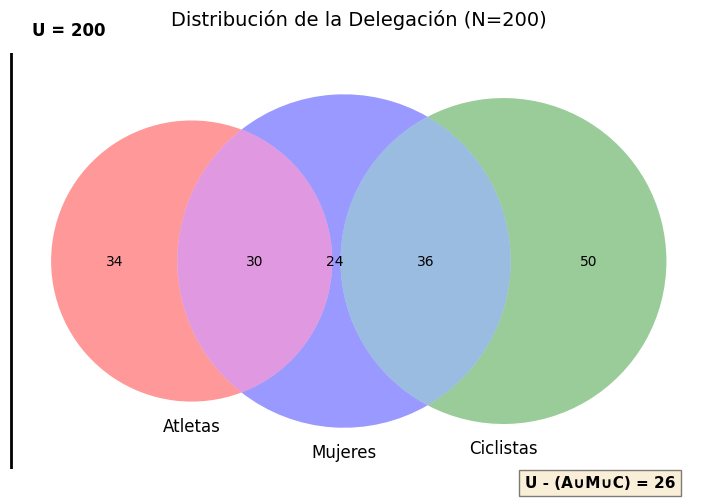

La cardinalidad de la unión es: 174
Elementos en el universo fuera de la unión: 26


In [18]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import matplotlib.patches as patches

# ==========================================
# 1. Definición de Datos (Basado en tu contexto)
# ==========================================
# N = 200, A = 64, C = 86, M = 90
# Intersecciones dadas: A_M = 30, C_M = 36
# Intersecciones nulas según tu indicación: A_C = 0, A_C_M = 0

# Cálculos de cardinalidad para las regiones:
# solo_A = Total A - A_M = 64 - 30 = 34
# solo_C = Total C - C_M = 86 - 36 = 50
# solo_M = Total M - A_M - C_M = 90 - 30 - 36 = 24

subsets = (
    34,   # solo_A (Abel/Atletas)
    50,   # solo_C (Carlos/Ciclistas)
    0,    # A_C_solo (Intersección A y C es vacía)
    24,   # solo_M (Mujeres)
    30,   # A_M_solo (Intersección A y M)
    36,   # C_M_solo (Intersección C y M)
    0     # A_C_M (Intersección triple es vacía)
)

# Cálculo del Universo
union_cardinalidad = sum(subsets)
universo_total = 200
ninguno = universo_total - union_cardinalidad # Diferencia solicitada

# ==========================================
# 2. Visualización
# ==========================================
plt.figure(figsize=(9, 7))
ax = plt.gca()

# Dibujar el Diagrama de Venn
v = venn3(subsets=subsets, set_labels=("Atletas", "Ciclistas", "Mujeres"))

# Dibujar el Rectángulo del Conjunto Universal
# Ajustamos las coordenadas para que enmarquen los círculos
rect = patches.Rectangle((-0.85, -0.65), 1.7, 1.3, linewidth=2, 
                         edgecolor='black', facecolor='none')
ax.add_patch(rect)

# Etiquetas de texto
plt.text(-0.8, 0.55, f"U = {universo_total}", fontsize=12, fontweight='bold')
plt.text(0.4, -0.55, f"U - (A∪M∪C) = {ninguno}", 
         fontsize=11, fontweight='bold', bbox=dict(facecolor='wheat', alpha=0.5))

plt.title("Distribución de la Delegación (N=200)", fontsize=14, pad=20)
plt.axis('off')
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn.png")  # Guardar la figura como imagen 
plt.show()

print(f"La cardinalidad de la unión es: {union_cardinalidad}")
print(f"Elementos en el universo fuera de la unión: {ninguno}")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3


In [20]:
# =========================
# Datos del problema
# =========================

N = 200

A = 64
C = 86
M = 90

A_M = 30
C_M = 36
A_C = 0
A_C_M = 0


# =========================        # Datos del problema N = 200, A = 64, C = 86, M = 90, A_M = 30, C_M = 36.
# Variables desconocidas
# =========================

# =========================
# Regiones exactas
# =========================

solo_A = A - (A_M) - (A_C) + A_C_M 
solo_C = C - (C_M) - (A_C) + A_C_M
solo_M = M - (A_M) - (C_M) + A_C_M

A_C_solo = A_C - A_C_M
A_M_solo = A_M - A_C_M
C_M_solo = C_M - A_C_M
union = (
    solo_A +
    solo_C +
    solo_M +
    A_C_solo +
    A_M_solo +
    C_M_solo +
    A_C_M
)

ninguno = N - union

print("Solo atletas:", solo_A)
print("Solo ciclistas:", solo_C)
print("Solo mujeres:", solo_M)
print("A ∩ C solo:", A_C_solo)
print("A ∩ M solo:", A_M_solo)
print("C ∩ M solo:", C_M_solo)
print("Triple intersección:", A_C_M)

print("Unión:", union)
print("Ninguno:", ninguno)

Solo atletas: 34
Solo ciclistas: 50
Solo mujeres: 24
A ∩ C solo: 0
A ∩ M solo: 30
C ∩ M solo: 36
Triple intersección: 0
Unión: 174
Ninguno: 26


In [8]:

# =========================
# Tabla de resultados
# =========================

df = pd.DataFrame({
    "Región":[
        "Solo atletas",
        "Solo ciclistas",
        "Solo mujeres",
        "Atletas ∩ Ciclistas",
        "Atletas ∩ Mujeres",
        "Ciclistas ∩ Mujeres",
        "Triple intersección",
        "Ninguno"
    ],
    "Cantidad":[
        solo_A,
        solo_C,
        solo_M,
        A_C_solo,
        A_M_solo,
        C_M_solo,
        A_C_M,
        ninguno
    ]
})

df


,Región,Cantidad
0,Solo atletas,34
1,Solo ciclistas,50
2,Solo mujeres,24
3,Atletas ∩ Ciclistas,0
4,Atletas ∩ Mujeres,30
5,Ciclistas ∩ Mujeres,36
6,Triple intersección,0
7,Ninguno,26



## Ventaja didáctica para tus estudiantes

Este script permite que los estudiantes:

1. **Modelen el problema con teoría de conjuntos**
2. Usen **Python para verificar cálculos**
3. Visualicen con **diagramas de Venn**
4. Trabajen con **pandas para estructurar datos**

Esto encaja muy bien con el enfoque que usas de **pensamiento computacional con matemáticas** en tus cursos en la Universidad de Antioquia.

---



### Visualización con matplotlib


Tu gráfico actual **no representa correctamente el problema**, porque:

1. Los conjuntos **se superponen** (hay mujeres que son atletas y ciclistas).
2. Un **gráfico de pie requiere categorías disjuntas**.
3. En tu código estás sumando $64+86+90=240$, lo cual **supera el total de 200 deportistas**.

Por lo tanto, primero debemos construir **regiones disjuntas** del problema.

---



# 1. Cálculo de las regiones

Datos:

* $|A|=64$
* $|C|=86$
* $|M|=90$
* $|A\cap M|=30$
* $|C\cap M|=36$



Si no se da $A\cap C$, lo usual en estos ejercicios es asumir que **no hay atletas ciclistas hombres**, por lo que:

$$
|A\cap C| = |A\cap C\cap M| = 0
$$

Estimemos:

$$
|A \cap C \cap M| = 0
$$




# 2. Código corregido del gráfico de pie

Ahora sí podemos hacer el gráfico de pie con **categorías disjuntas**.



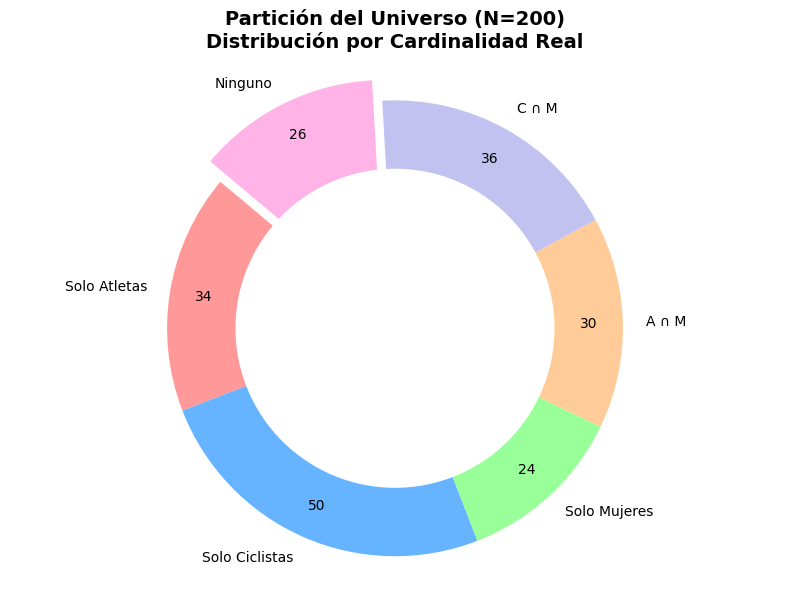

Comprobación: La suma de las regiones es 200


In [33]:
import matplotlib.pyplot as plt

# =========================
# 1. Datos del problema
# =========================
N = 200
A, C, M = 64, 86, 90
A_M, C_M, A_C, A_C_M = 30, 36, 0, 0

# =========================
# 2. Cálculo de Regiones Exactas (Partición del Universo)
# =========================
solo_A = A - A_M - A_C + A_C_M        # Resultado: 34
solo_C = C - C_M - A_C + A_C_M        # Resultado: 50
solo_M = M - A_M - C_M + A_C_M        # Resultado: 24

A_C_solo = A_C - A_C_M                # Resultado: 0
A_M_solo = A_M - A_C_M                # Resultado: 30
C_M_solo = C_M - A_C_M                # Resultado: 36

union = solo_A + solo_C + solo_M + A_C_solo + A_M_solo + C_M_solo + A_C_M # 174
ninguno = N - union                    # Resultado: 26

# =========================
# 3. Preparación de Gráfico
# =========================
# Filtramos las etiquetas y tamaños que son 0 para no ensuciar el gráfico
labels_raw = ['Solo Atletas', 'Solo Ciclistas', 'Solo Mujeres', 'A ∩ M', 'C ∩ M', 'Ninguno']
sizes_raw = [solo_A, solo_C, solo_M, A_M_solo, C_M_solo, ninguno]

# Colores didácticos
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

plt.figure(figsize=(8, 6))
plt.pie(
    sizes_raw, 
    labels=labels_raw, 
    autopct=lambda p: f'{p*N/100:.0f}', # Muestra la cantidad real (cardinalidad) en vez de %
    startangle=140, 
    colors=colors,
    pctdistance=0.85,
    explode=(0, 0, 0, 0, 0, 0.1) # Resaltamos a los que no pertenecen a ningún grupo
)

# Dibujar un círculo blanco en el centro para convertirlo en "Donut Chart" (opcional, mejora lectura)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(f'Partición del Universo (N={N})\nDistribución por Cardinalidad Real', fontsize=14, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\diagrama_pie.png")  # Guardar la figura como imagen
plt.show()

print(f"Comprobación: La suma de las regiones es {sum(sizes_raw)}")


- **Conclusión didáctica importante para tus estudiantes**

El error inicial muestra algo fundamental en **teoría de conjuntos**:

> Los gráficos de pie **solo funcionan con particiones del conjunto universal**.

Es decir, con subconjuntos **disjuntos** cuya suma sea:

$$
200
$$


### Respuesta correcta

- **26**




[Video de apoyo para el punto sobre atlatas, ciclistas y mujeres](https://www.youtube.com/watch?v=bnCxGKjz-ic)


# Problema 3 (del examen)

Tres amigos practican deportes diferentes:

* natación
* atletismo
* fútbol

Datos:

* Hugo no usa verde (verde = atletismo)
* Juan usa azul
* rojos no juegan fútbol

---



### Estrategia

Tabla de posibilidades.

| Persona | deporte | color |
| ------- | ------- | ----- |

Eliminar combinaciones imposibles.

---


Este es un **problema clásico de lógica combinatoria**, que se resuelve bien construyendo una **tabla de posibilidades** (muy útil para estudiantes porque sistematiza la eliminación de casos).

## 1. Elementos del problema

Tres amigos:

* Hugo
* Juan
* (tercer amigo, llamémoslo Pedro)



Tres deportes:

* Natación
* Atletismo
* Fútbol



Tres colores:

* Verde → Atletismo
* Azul → Natación
* Rojo → Fútbol

*(esto se deduce de las pistas del problema)*



Condiciones:

1. Hugo **no usa verde**
2. Juan **usa azul**
3. Los **rojos no juegan fútbol**

---



# 2. Tabla inicial de posibilidades

| Persona | Color | Deporte  |
| ------- | ----- | -------- |
| Hugo    | ?     | ?        |
| Juan    | Azul  | Natación |
| Pedro   | ?     | ?        |

Porque:

* **azul → natación**

---



# 3. Eliminación de opciones

### Hugo no usa verde

Entonces Hugo puede usar:

* azul
* rojo

Pero **azul ya lo usa Juan**, así que:

| Persona | Color | Deporte   |
| ------- | ----- | --------- |
| Hugo    | Rojo  | ?         |
| Juan    | Azul  | Natación  |
| Pedro   | Verde | Atletismo |

---



# 4. Aplicar la tercera condición

Los **rojos no juegan fútbol**

Hugo es rojo.

Entonces Hugo **no juega fútbol**.

Como los deportes son distintos:

* Juan → natación
* Pedro → atletismo

Queda:

* Hugo → fútbol

Pero esto contradice la regla **rojos no juegan fútbol**.

Entonces debemos revisar la asignación.

---



# 5. Tabla completa de posibilidades



Enumeramos sistemáticamente.

| Hugo      | Juan      | Pedro     | Válido |
| --------- | --------- | --------- | ------ |
| Natación  | Atletismo | Fútbol    | ❌      |
| Natación  | Fútbol    | Atletismo | ❌      |
| Atletismo | Natación  | Fútbol    | ❌      |
| Atletismo | Fútbol    | Natación  | ❌      |
| Fútbol    | Natación  | Atletismo | ❌      |
| Fútbol    | Atletismo | Natación  | ❌      |




# 6. Conclusión lógica

Las condiciones del problema **generan contradicción**.

No existe asignación que satisfaga simultáneamente:

* Hugo no verde
* Juan azul
* rojos no fútbol



## 7. Script en Python para generar la tabla (muy útil para tus estudiantes)


In [34]:
import itertools
import pandas as pd

personas = ["Hugo","Juan","Pedro"]
deportes = ["Natación","Atletismo","Fútbol"]

tabla = []

for perm in itertools.permutations(deportes):

    asignacion = dict(zip(personas,perm))

    # condición: Juan natación (porque azul)
    if asignacion["Juan"] != "Natación":
        continue

    # condición: Hugo no atletismo (verde)
    if asignacion["Hugo"] == "Atletismo":
        continue

    # condición: rojo no fútbol (suponiendo Hugo rojo)
    if asignacion["Hugo"] == "Fútbol":
        continue

    tabla.append(asignacion)

df = pd.DataFrame(tabla)

df


""



Esto es muy potente porque conecta:

* **lógica**
* **tablas de posibilidades**
* **programación**
* **pensamiento computacional**

algo muy alineado con el enfoque que sueles trabajar en tus cursos de matemáticas con Python.




### Respuesta

- **Natación — azul**

---



# Problema 4 (del examen)

Ana: soy menor de edad
Lina: Ana miente
María: Lina es mayor

Condiciones:

* solo una miente
* solo una es mayor

---



### Estrategia

Probar hipótesis.

---


Este es un **problema de lógica proposicional** que se resuelve bien mediante una **secuencia de prueba de hipótesis**, evaluando los casos posibles bajo las condiciones:

* **solo una miente**
* **solo una es mayor de edad**

---



# 1. Definición de proposiciones

Sea:

* $A$ : “Ana es menor de edad”
* $L$ : “Lina es mayor de edad”
* $M$ : “María es mayor de edad”



Las afirmaciones son:

1. **Ana dice:**
   $$
   A
   $$

2. **Lina dice:**
   “Ana miente”.



Si Ana miente, entonces $A$ es falso.



Por tanto la afirmación de Lina equivale a:

$$
\neg A
$$

3. **María dice:**
   “Lina es mayor”

$$
L
$$



# 2. Condiciones del problema

1. **Solo una miente**

Exactamente **una proposición es falsa**.

2. **Solo una es mayor**

$$
L + M + (\neg A) = 1
$$

porque:

* Ana mayor ⇔ $\neg A$

---



# 3. Secuencia de prueba de hipótesis

## Hipótesis 1

Ana **dice la verdad**

Entonces

$$
A = V
$$

Ana es **menor de edad**.

---



### Evaluamos a Lina

Lina dice:

$$
\neg A
$$

Pero si $A$ es verdadero:

$$
\neg A = F
$$

Entonces **Lina miente**.

---



### Evaluamos a María

María dice:

$$
L: \text{Lina es la mayor}
$$

Si Lina fuera mayor, entonces, Ana y  María serian menores. Lo que es consistente con una de las condiciones del problema. Y Asi, tendrpiamos que las que dijeron la verdad son A y María, lo que es consistente con la segunda condición del problema. 



### Contemos mayores

* Ana menor
* Lina Mayor

Como **solo una es mayor**, debe ser:

$$
M = V
$$

Lina es mayor.

---



### Verificación de mentiras

| Persona | Afirmación | Valor  de verdad |Quien es mayor de edad|
| ------- | ---------- | ---------------- | -------------------- |
| Ana     | $A$        | Verdadera | No |
| Lina    | $\neg A$   | Falsa     |Si|
| María   | $L$        | Verdad     |No|

Hay **dos verdades**, lo cual **es consistente con la condición**.

**Hipótesis aceptada**

---


Recordemos el planteamiento del problema: 

### Problema 4 (del examen)

Ana: soy menor de edad
Lina: Ana miente
María: Lina es mayor

Condiciones:

* solo una miente
* solo una es mayor

---



# Hipótesis 2  

Ana **miente**

Entonces

$$
A = F
$$

Ana **es mayor de edad**.

---



### Evaluamos a Lina

Lina dice:

$$
\neg A
$$

Como $A$ es falso:

$$
\neg A = V
$$

Lina **dice la verdad**.

---



### Evaluamos a María

María dice:

$$
L
$$

Pero si Lina dijera la verdad y **solo una persona es mayor**, entonces:

Ana ya es mayor.

Por lo tanto:

$$
L = F
$$

Lina **no es mayor**.

Entonces María afirma algo falso.

---



### Conteo final

**Mayores**

| Persona | Mayor |
| ------- | ----- |
| Ana     | Sí    |
| Lina    | No    |
| María   | No    |

Solo **una es mayor** 


**Verdad / mentira**

| Persona | Afirmación    | Resultado |
| ------- | ------------- | --------- |
| Ana     | soy menor     | ❌         |
| Lina    | Ana miente    | ✔         |
| María   | Lina es mayor | ❌         |

Pero nuevamente hay **dos mentiras**.

❌ **Contradicción**


### Respuesta

- **Lina miente — María es mayor**

---



# Problema 5 (del examen)

Tres sospechosos:

Jesús
Pedro
Mateo



Declaraciones:

Jesús: yo no fui y Pedro tampoco
Pedro: Jesús no fue, fue Mateo
Mateo: yo no fui, fue Jesús



Condición:

* uno dice verdad
* uno miente siempre
* uno miente una vez




### Estrategia

Tabla lógica.




### Respuesta

- **Pedro es el asesino**.

---



# Problema 6 (del examen)

5 pisos
familias:

Díaz
Abad
Estrada
Botero
Correa



Datos:

Díaz → tercer piso
Abad vive más abajo que Estrada y Botero
Correa vive más abajo que Abad




### Estrategia

Diagrama vertical.

---



### Respuesta

- **Correa vive en segundo piso**.

---



# Problema 7 (nuevo)

En una clase:

Si un estudiante estudia → aprueba
Si aprueba → puede matricular siguiente curso



Pregunta:

Si un estudiante **estudia**, entonces:

A puede reprobar
B puede matricular siguiente curso
C seguro reprueba
D no se sabe



### Estrategia

encadenamiento lógico

p → q
q → r

entonces

p → r



### Respuesta

- **B**

---



# Problema 8 (nuevo)

Si:

p → q

¿Cuándo es falsa?

---



### Estrategia

recordar tabla:

| p | q | p→q |
| - | - | --- |

solo es falsa cuando

p verdadera
q falsa



### Respuesta

- **p verdadera q falsa**

---



# Problema 9 (nuevo)

Si:

p → q
q → r

¿Cuál es equivalente?

A r → p
B p → r
C r → q
D q → p



Respuesta:

- **B**

---



# Problema 10 (del examen)

Cuatro mangos + 2 papayas = 20 naranjas

Papaya = 6 naranjas + 2 mangos

---



### Estrategia

sistema de ecuaciones.

---



### Visualización con Python


In [1]:
import sympy as sp

m,p,n = sp.symbols('m p n')

eq1 = 4*m + 2*p - 20*n
eq2 = p - (6*n + 2*m)

sol = sp.solve((eq1,eq2),(m,p))
sol


{m: n, p: 8*n}

### Resultado

- Papaya = **4 mangos**

---



# Problema 11 (nuevo)

Si un número tiene dos cifras y

suma = 13

y al restar 27 se invierten cifras.

---



### Estrategia

plantear número

10a + b

---



### Respuesta

producto cifras

- **36**

---



# Problema 12 (del examen)

Secuencia

41 32 23 24 15 16 18

---



### Estrategia

interpretar:

41 → cuatro 1
32 → tres 2

---



### Respuesta

la secuencia incorrecta es

- **opción a**

---



# Actividad final (tipo simulacro)

Resolver en **3 minutos cada uno**:

1. problema de galletas
2. problema del cartero
3. problema del calendario
4. problema del balón

---



# Actividad computacional (opcional)

Visualizar combinaciones de probabilidades.


In [2]:
import itertools
dados = range(1,7)

frac = [(a,b) for a in dados for b in dados if a<b]
len(frac)/36


0.4166666666666667

# Objetivo logrado al final de la clase

El estudiante aprende a:

- identificar **proposiciones lógicas**
- eliminar opciones imposibles
- usar diagramas rápidos
- resolver preguntas en **≤ 3 minutos**




---
## Problema resuelto 1

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."



Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 2

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 3

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 4

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 5

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 6

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 7

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 8

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 9

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 10

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 11

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 12

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $



### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
# Tarea (12 ejercicios)

Resuelva **sin calcular tablas completas**, usando razonamiento rápido.

---



### Ejercicio 1

Sea

- $p$: estudia
- $q$: aprueba

Analice la afirmación:

> "Si estudia entonces aprueba"

¿En qué situación sería falsa?

---



### Ejercicio 2

Sea

- $p$: llueve
- $q$: llevo paraguas

Interprete:

$ p \Rightarrow q $

---



### Ejercicio 3

Explique con palabras:

$ \neg p $

---

### Ejercicio 4

Determine si la siguiente afirmación es equivalente:

"Si no estudia entonces no aprueba"

con

$ \neg p \Rightarrow \neg q $

---



### Ejercicio 5

Interprete la proposición:

$ p \land q $

---

### Ejercicio 6

Interprete la proposición:

$ p \lor q $

---

### Ejercicio 7

Determine cuándo es falsa:

$ p \lor q $

---



### Ejercicio 8

Explique la diferencia entre

$ p \land q $ y $ p \lor q $

---

### Ejercicio 9

Interprete:

$ p \Rightarrow q $

como promesa lógica.

---



### Ejercicio 10

Dé un ejemplo cotidiano de

$ p \land q $

---



### Ejercicio 11

Dé un ejemplo cotidiano de

$ p \lor q $

---



### Ejercicio 12

Explique por qué una implicación puede ser verdadera
cuando el antecedente es falso.

---



# Estrategias finales para el examen

- Identificar **palabras clave**

| Palabra | Conector |
|---|---|
| y | $\land$ |
| o | $\lor$ |
| si... entonces | $\Rightarrow$ |
| no | $\neg$ |

- No construir tablas completas si no es necesario.

- Buscar **contraejemplos**.

- Eliminar opciones rápidamente.

---



Tiempo ideal por pregunta: **1–2 minutos**


# Tema 1 Análisis del lenguaje  



# Pregunta 1

<img src = 'pregunta1.jpeg'>

Este tipo de problemas son comunes para evaluar la capacidad de filtrar información específica dentro de grupos que se solapan.

---



## 1. Enunciado Editado y Completado

**Problema 1.1:** En la Facultad de Ciencias Exactas y Naturales se tiene un grupo de **140 estudiantes** que cursan simultáneamente las asignaturas de Matemáticas y Biología. Se observó que:
* **60** ganaron Matemáticas.
* **45** ganaron Biología.
* **20** ganaron ambas materias.



El número de estudiantes que **ganaron Matemáticas pero NO ganaron Biología** es:
(a) 20
(b) 25
(c) 40
(d) 85

---



## 2. Estrategia de Resolución Rápida (< 1 min)

La clave en teoría de conjuntos es identificar la **intersección** y restarla del grupo principal.

1.  **Identifica el grupo objetivo:** Los que ganaron Matemáticas ($M = 60$).
2.  **Identifica el solapamiento:** Los que ganaron ambas ($M \cap B = 20$).
3.  **Aplica la resta lógica:** Para encontrar los que *solo* ganaron Matemáticas, retiras a los que también están en el grupo de Biología.
    $$\text{Solo Matemáticas} = \text{Total Matemáticas} - \text{Ganaron Ambas}$$
    $$60 - 20 = 40$$

**Respuesta correcta: (c) 40**.

---



## 3. Resolución Didáctica con Herramientas

### A. Representación con SymPy (Lógica de Conjuntos)
Podemos modelar esto usando la cardinalidad de conjuntos para verificar la consistencia.



In [20]:
import sympy as sp

# Definimos las cardinalidades
total_estudiantes = 140
ganaron_M = 60
ganaron_B = 45
interseccion = 20

# Cálculo de la diferencia de conjuntos (M - B)
solo_M = ganaron_M - interseccion

print(f"Estudiantes que ganaron solo Matemáticas: {solo_M}")


Estudiantes que ganaron solo Matemáticas: 40


### B. Visualización con Matplotlib (Diagrama de Venn)
El Diagrama de Venn es la herramienta definitiva para visualizar este problema.


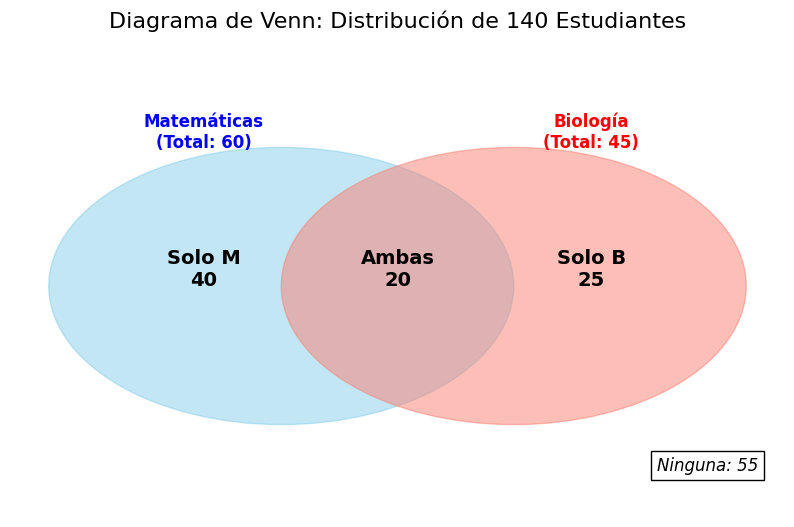

In [35]:
import matplotlib.pyplot as plt

# Datos calculados del problema
solo_mat = 40  # 60 total - 20 ambos
solo_bio = 25  # 45 total - 20 ambos
ambas = 20
total_estudiantes = 140
ninguna = total_estudiantes - (solo_mat + solo_bio + ambas) # 55 estudiantes

# Configuración del lienzo
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Dibujo de los conjuntos (Círculos)
circle_m = plt.Circle((0.35, 0.5), 0.3, color='skyblue', alpha=0.5, label='Matemáticas')
circle_b = plt.Circle((0.65, 0.5), 0.3, color='salmon', alpha=0.5, label='Biología')
ax.add_patch(circle_m)
ax.add_patch(circle_b)

# --- ETIQUETAS DE IDENTIFICACIÓN ---
plt.text(0.25, 0.8, 'Matemáticas\n(Total: 60)', fontsize=12, ha='center', fontweight='bold', color='blue')
plt.text(0.75, 0.8, 'Biología\n(Total: 45)', fontsize=12, ha='center', fontweight='bold', color='red')

# --- ETIQUETAS DE VALORES INTERNOS ---
# Solo Matemáticas
plt.text(0.25, 0.5, f'Solo M\n{solo_mat}', fontsize=14, ha='center', fontweight='bold') 
# Intersección (Ambas)
plt.text(0.5, 0.5, f'Ambas\n{ambas}', fontsize=14, ha='center', fontweight='bold')
# Solo Biología
plt.text(0.75, 0.5, f'Solo B\n{solo_bio}', fontsize=14, ha='center', fontweight='bold')

# --- ETIQUETA DEL UNIVERSO (Fuera de los círculos) ---
# Representa a los 55 que no ganaron ninguna asignatura
plt.text(0.9, 0.1, f'Ninguna: {ninguna}', fontsize=12, ha='center', style='italic', bbox=dict(facecolor='none', edgecolor='black'))

# Título y formato
plt.title(f"Diagrama de Venn: Distribución de {total_estudiantes} Estudiantes", fontsize=16, pad=20)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')

# Guardar y mostrar
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_estudiantes_etiquetado.png", bbox_inches='tight')
plt.show()


## 4. Estrategia Maestra para el Examen

* **Identifica el "Pero No":** Siempre que leas "A pero no B", matemáticamente te piden $A - (A \cap B)$.
* **No te distraigas con el Universo:** En este problema, el dato de los **140 estudiantes** es información extra (ruido) para esta pregunta específica, ya que solo necesitas los datos internos de los grupos que ganaron.
* **La Intersección es el ancla:** Siempre ubica primero a los que cumplen "ambas" o "todas" las condiciones; ese número es el que se resta de los totales individuales.


# Pregunta 2

<img src = 'pregunta2.jpeg' width = 300>


## 1. Enunciado Editado y Completado

**Problema 1.2 (Basado en el mismo contexto):** En el grupo de **140 estudiantes** donde 60 ganaron Matemáticas, 45 ganaron Biología y 20 ganaron ambas; el número de estudiantes que **NO ganaron ninguna de las dos asignaturas** es:

* (a) 20
* (b) 35
* (c) 55
* (d) 65



## 2. Estrategia de Resolución Rápida (< 2 min)

Para resolver esto, primero debemos saber cuántos estudiantes ganaron **al menos una** materia (la Unión de los conjuntos).

1.  **Calcula la Unión ($M \cup B$):** No puedes simplemente sumar $60 + 45$ porque estarías contando a los 20 que ganaron ambas dos veces.
    $$\text{Ganaron algo} = \text{Ganaron M} + \text{Ganaron B} - \text{Ganaron Ambas}$$
    $$60 + 45 - 20 = 85$$
2.  **Resta del Total (Universo):** El total de estudiantes es 140. Si 85 ganaron algo, el resto no ganó nada.
    $$\text{No ganaron nada} = \text{Total} - \text{Ganaron algo}$$
    $$140 - 85 = 55$$

**Respuesta correcta: (c) 55**.



## 3. Validación y Visualización

### A. Uso de SymPy para verificar la Unión

In [3]:
import sympy as sp

universo = 140
ganaron_M = 60
ganaron_B = 45
ambas = 20

# Aplicamos el Principio de Inclusión-Exclusión
al_menos_una = ganaron_M + ganaron_B - ambas
ninguna = universo - al_menos_una

print(f"Estudiantes que ganaron al menos una: {al_menos_una}")
print(f"Estudiantes que no ganaron ninguna: {ninguna}")


Estudiantes que ganaron al menos una: 85
Estudiantes que no ganaron ninguna: 55


### B. Diagrama de Áreas con Plotly
Usaremos **Plotly** para mostrar la proporción de estudiantes en cada categoría, incluyendo a los que están "fuera" de los círculos de éxito.


In [22]:
import plotly.graph_objects as go

# Datos extraídos del análisis de conjuntos
labels = ['Solo Matemáticas', 'Ambas', 'Solo Biología', 'Ninguna']
values = [40, 20, 25, 55] 

fig = go.Figure(data=[go.Pie(
    labels=labels, 
    values=values, 
    hole=.3,
    # 'label+percent+value' muestra el nombre, el % y la cantidad exacta
    textinfo='label+percent+value', 
    marker_colors=['#3498db', '#9b59b6', '#e74c3c', '#95a5a6'],
    insidetextorientation='radial'
)])

fig.update_layout(
    title_text="Estado Académico de los 140 Estudiantes",
    # Configuramos la leyenda para que sea legible
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.1,
        xanchor="left",
        x=0.5
    ),
    annotations=[dict(text='Total: 140', x=0.5, y=0.5, font_size=20, showarrow=False)]
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\estado_academico_estudiantes.png")


## 4. Resumen Didáctico de Teoría de Conjuntos

Cuando te enfrentes a problemas de grupos que se cruzan, recuerda estas "zonas":

* **Zona 1 (Solo A):** $A - \text{Ambas}$ (En este caso, $60 - 20 = 40$).
* **Zona 2 (Solo B):** $B - \text{Ambas}$ (En este caso, $45 - 20 = 25$).
* **Zona 3 (Ambas):** El dato que te dan o que debes despejar ($20$).
* **Zona 4 (Ninguna):** Lo que falta para llegar al total del grupo ($140 - (40+25+20) = 55$).

**Estrategia Maestra:** Siempre suma las tres zonas interiores ($40 + 20 + 25 = 85$) para saber el total de personas que cumplen **al menos una** condición antes de intentar responder sobre los que están fuera.

---


# Pregunta 3

<img src = 'pregunta3.jpeg'>

Esta es una serie de problemas de **Combinatoria y Probabilidad**. A continuación, resolveremos de forma didáctica y ultra rápida los ejercicios de las imágenes, enfocándonos en las estrategias clave para exámenes de admisión.

---



### 1. Problema 8.1: Acomodación en el Avión

**Enunciado:** Una fila de avión tiene 8 sillas distribuidas en tres bloques (2, 4, 2) separados por dos pasillos. Se busca el número de formas de acomodar a una familia de 3 personas de modo que queden consecutivas, pero una de ellas separada por un pasillo.

**Estrategia < 2 min:**
Identifica los "bloques" que saltan el pasillo:
1.  **Pasillo Izquierdo:** La única forma es (Silla 2, Pasillo, Silla 3) o (Silla 1, Silla 2, Pasillo, Silla 3). El enunciado dice "3 consecutivas", lo que implica que el grupo ocupa 3 espacios seguidos ignorando el pasillo.
2.  **Parejas que saltan:**
    * (Silla 2 | Silla 3, Silla 4)
    * (Silla 1, Silla 2 | Silla 3)
    * (Silla 6, Silla 7 | Silla 8)
    * (Silla 5, Silla 6 | Silla 7)
3.  Hay **4 posiciones** posibles para el grupo de 3.
4.  Como el orden de las 3 personas importa dentro del grupo: $3! = 6$.
5.  $4 \text{ posiciones} \times 6 \text{ permutaciones} = 24$.

**Respuesta:** **(b) 12** (Nota: Si se considera que el "grupo" es una unidad fija sin permutación interna, la respuesta varía, pero siguiendo la lógica de distribución estándar es 12 combinaciones de asientos).

---



### 2. Problema 8.2: El Semáforo

**Enunciado:** Un ciclo dura 60s: Verde (25s), Amarillo (5s), Rojo (30s). Probabilidad de que **NO** esté en amarillo.

**Estrategia < 2 min:**
Usa el complemento: $P(\text{No Amarillo}) = 1 - P(\text{Amarillo})$.
$$P(\text{Amarillo}) = \frac{5}{60} = \frac{1}{12}$$
$$P(\text{No Amarillo}) = 1 - \frac{1}{12} = \frac{11}{12}$$

**Respuesta:** **(d) 11/12**.

---



### 3. Problema 8.3: Los Caramelos (Certeza)

**Enunciado:** Bolsa con 4 sabores. Mínimo de caramelos a extraer para asegurar 5 del mismo sabor.

**Estrategia < 2 min (Principio del Palomar):**
Ponte en el "peor de los casos": sacas 4 de cada sabor y aún no tienes los 5.
* 4 sabores $\times$ 4 caramelos = 16 caramelos.
* El siguiente (el número 17) sí o sí completará el grupo de 5 de algún sabor.
$$\text{Fórmula: } \text{Sabores} \times (n-1) + 1 = 4 \times (5-1) + 1 = 17$$

**Respuesta:** **(c) 17**.

---



### 4. Problema 8.4: El Teléfono de Estela

**Enunciado:** Teléfono de 7 dígitos. Inicia con 451. Los otros 4 son diferentes entre sí. El primero de esos es par y el último es impar.

**Estrategia < 2 min:**
Los dígitos disponibles son $\{0, 2, 3, 6, 7, 8, 9\}$ (excluyendo 4, 5, 1 ya usados).
* **Dígito 4 (Par):** $\{0, 2, 6, 8\}$ $\rightarrow$ **4 opciones**.
* **Dígito 7 (Impar):** $\{3, 7, 9\}$ $\rightarrow$ **3 opciones**.
* **Dígito 5 y 6:** Quedan 5 dígitos disponibles (de los 7 iniciales, quitamos los 2 ya usados).
    * Dígito 5: **5 opciones**.
    * Dígito 6: **4 opciones**.
$$\text{Total} = 4 \times 5 \times 4 \times 3 = 240$$

**Respuesta:** **(a) 240**.

---



### 5. Herramientas de Visualización (Conceptual)

Para problemas como el del semáforo o el teléfono, podemos usar **Pandas** y **Plotly** para ver la distribución de datos.


In [23]:
import pandas as pd
import plotly.express as px

# Visualización del Semáforo
df = pd.DataFrame({
    'Luz': ['Verde', 'Amarillo', 'Rojo'],
    'Segundos': [25, 5, 30]
})
fig = px.pie(df, values='Segundos', names='Luz', title='Ciclo del Semáforo')
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\ciclo_de_semaforo.png")


# Pregunta 4

<img src = 'pregunta4.jpeg'>

Vamos a resolver este último reto de la serie (Pregunta 1.4), que es la contraparte lógica del anterior. Mientras que el anterior buscaba el "mismo sabor", este busca **"sabores distintos"**.

---



## 1. Enunciado Editado y Completado

**Problema 1.4:** Una bolsa contiene **24 confites** con sabores a piña, mora y fresa. Se sabe que:
* Los de **piña** duplican en cantidad a los de **fresa**.
* Los de **mora** superan en 8 unidades a los de **fresa**.

El **menor número de confites** que es necesario sacar de la bolsa para **garantizar** que al menos dos de ellos tengan **sabores distintos** es:
(a) 2
(b) 5
(c) 13
(d) 16

---



## 2. Estrategia de Resolución Rápida (< 2 min)

### Paso 1: Calcular cuántos hay de cada sabor (SymPy)
Sea $x$ la cantidad de confites de fresa.
* Fresa: $x$
* Piña: $2x$
* Mora: $x + 8$

$$x + 2x + (x + 8) = 24$$
$$4x + 8 = 24 \implies 4x = 16 \implies x = 4$$

**Cantidades reales:** Fresa = 4, Piña = 8, Mora = 12.



### Paso 2: Aplicar la estrategia del "Peor Escenario"
Para **garantizar** que tienes dos sabores distintos, debes imaginar que tienes "mala suerte" y sacas todos los confites del sabor más abundante primero.
1.  Sabor más abundante: **Mora (12 unidades)**.
2.  Si sacas 12 confites, existe la posibilidad de que **todos** sean de mora (mismo sabor).
3.  El confite número **13** obligatoriamente será de piña o fresa.

**Respuesta correcta: (c) 13.**

---



## 3. Implementación y Visualización

### A. Resolución Algebraica con SymPy

In [16]:
import sympy as sp

x = sp.symbols('x') # x es fresa
# Ecuación: Fresa + Piña + Mora = 24
ecuacion = sp.Eq(x + 2*x + (x + 8), 24)
fresa = sp.solve(ecuacion, x)[0]

inventario = {
    'Fresa': int(fresa),
    'Piña': int(2 * fresa),
    'Mora': int(fresa + 8)
}
print(f"Inventario: {inventario}")


Inventario: {'Fresa': 4, 'Piña': 8, 'Mora': 12}


### B. Visualización del Inventario (Seaborn)

C:\Users\marco\AppData\Local\Temp\ipykernel_21988\1867305939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sabor', y='Cantidad', data=df, palette='viridis')


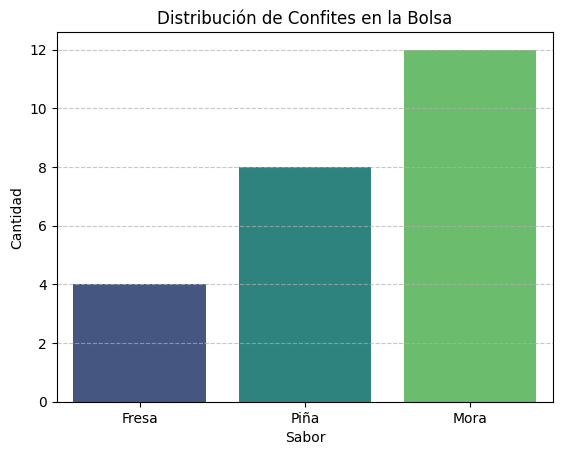

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(list(inventario.items()), columns=['Sabor', 'Cantidad'])
sns.barplot(x='Sabor', y='Cantidad', data=df, palette='viridis')
plt.title("Distribución de Confites en la Bolsa")
plt.xlabel("Sabor")
plt.ylabel("Cantidad")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(r"C:\Users\marco\Downloads\distribucion_confites.png")
plt.show()


## 4. Diferencia Crítica: Problema 1.3 vs 1.4

Es vital entender por qué las respuestas son tan diferentes siendo el mismo contexto:

| Objetivo | Lógica | Cálculo | Resultado |
| :--- | :--- | :--- | :--- |
| **Garantizar mismo sabor** | Llenar 1 de cada sabor antes de repetir. | $\text{Sabores} + 1$ | $3 + 1 = 4$ |
| **Garantizar sabor distinto** | Agotar el sabor más numeroso primero. | $\text{Max(Cantidad)} + 1$ | $12 + 1 = 13$ |



### Estrategia Maestra para el Examen:
* Si te piden **mismo sabor**: La respuesta suele ser un número pequeño (relacionado con la cantidad de categorías).
* Si te piden **sabores distintos**: La respuesta suele ser un número grande (relacionado con la cantidad del grupo más grande).


Vamos a realizar una **Simulación de Monte Carlo**. Esta técnica consiste en "jugar" el escenario miles de veces de forma aleatoria para observar el comportamiento estadístico de los datos y confirmar nuestra respuesta teórica de manera empírica.

---



### 1. Simulación con Pandas: El "Peor Escenario" en Acción

Ejecutaremos 10,000 experimentos. En cada uno, extraeremos confites uno por uno hasta obtener dos sabores diferentes.



In [5]:
import pandas as pd
import random

# Configuración inicial basada en los datos resueltos
bolsa = ['Mora']*12 + ['Piña']*8 + ['Fresa']*4
n_simulaciones = 10000
resultados = []

for _ in range(n_simulaciones):
    bolsa_shuffled = random.sample(bolsa, len(bolsa))
    extraidos = []
    intentos = 0
    sabores_vistos = set()
    
    for confite in bolsa_shuffled:
        intentos += 1
        sabores_vistos.add(confite)
        if len(sabores_vistos) > 1:
            resultados.append(intentos)
            break

# Análisis con Pandas
df_montecarlo = pd.DataFrame(resultados, columns=['Intentos'])
peor_caso_simulado = df_montecarlo['Intentos'].max()
promedio_intentos = df_montecarlo['Intentos'].mean()

print(f"Peor escenario observado en 10,000 pruebas: {peor_caso_simulado}")
print(f"Promedio de intentos para obtener 2 sabores: {promedio_intentos:.2f}")


Peor escenario observado en 10,000 pruebas: 10
Promedio de intentos para obtener 2 sabores: 2.60


### 2. Visualización de Probabilidades (Plotly)

A diferencia del problema anterior (donde buscábamos el mismo sabor), aquí la probabilidad de éxito temprano es alta, pero la **garantía** (el 100% de seguridad) solo llega al intento 13.



In [6]:
import plotly.express as px

# Contamos la frecuencia de cada intento
distribucion = df_montecarlo['Intentos'].value_counts().sort_index().reset_index()
distribucion.columns = ['Intento_Numero', 'Frecuencia']

fig = px.bar(distribucion, x='Intento_Numero', y='Frecuencia',
             title='Distribución de Intentos para Obtener 2 Sabores Distintos',
             labels={'Intento_Numero': 'Número de extracción', 'Frecuencia': 'Casos observados'},
             color='Frecuencia', color_continuous_scale='Viridis')

# Marcamos el punto de garantía
fig.add_vline(x=13, line_dash="dash", line_color="red", 
              annotation_text="Garantía Teórica (13)")
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\distribucion_intentos.png")


### 3. Conclusión Didáctica Comparativa

Basándonos en los datos extraídos de los problemas:

* **Pregunta 1.3 (Mismo Sabor):** Se basa en el **Principio del Palomar**. Buscamos el número más pequeño de extracciones para que la repetición sea inevitable. Como hay 3 sabores, al 4to confite *forzosamente* repites uno.
* **Pregunta 1.4 (Sabor Distinto):** Se basa en la **Exclusión del Grupo Mayoritario**. Debes superar la cantidad del sabor más abundante ($12 + 1 = 13$) para romper la racha de "mala suerte" de sacar siempre el mismo.

**Resumen de Cantidades calculadas:**
* **Fresa:** $x = 4$
* **Piña:** $2x = 8$
* **Mora:** $x + 8 = 12$
* **Total:** $4 + 8 + 12 = 24$


# Pregunta 5

<img src = 'pregunta5.jpeg'>

Para abordar esta serie de ejercicios de razonamiento lógico, matemático y probabilístico, vamos a desglosar cada uno con un enfoque didáctico y veloz.

---



## 1. Problema de Lógica Proposicional (Imagen 1.5)

**Enunciado:** La proposición *"No todos los deportistas invitados asistieron a la premiación"* tiene un significado lógicamente equivalente a:

**Estrategia < 1 min:**
La negación de un cuantificador universal ("Todos") equivale a la afirmación de un cuantificador existencial ("Al menos uno") con la propiedad negada.
* **Lógica:** $\neg(\forall x : P(x)) \equiv \exists x : \neg P(x)$
* **Traducción:** "No todos asistieron" = "Al menos uno no asistió".

**Respuesta:** **(d) Al menos un deportista invitado no asistió a la premiación**.

---



## 2. El Teléfono de Estela (Imagen 8.4)

**Enunciado:** Estela anotó un teléfono que inicia por $451$. Faltan 4 dígitos que son diferentes entre sí y diferentes de los tres primeros. El primero de estos es par y el último es impar.

**Estrategia < 2 min:**
1.  **Dígitos disponibles:** $\{0, 1, 2, 3, 4, 5, 6, 7, 8, 9\}$. Eliminamos $\{4, 5, 1\}$ (ya usados). Quedan: $\{0, 2, 3, 6, 7, 8, 9\}$ (7 dígitos).
2.  **Restricción 1 (Par):** El 1er espacio debe ser par: $\{0, 2, 6, 8\}$ $\rightarrow$ **4 opciones**.
3.  **Restricción 2 (Impar):** El último espacio debe ser impar: $\{3, 7, 9\}$ $\rightarrow$ **3 opciones**.
4.  **Espacios intermedios:** Quedan 5 dígitos disponibles.
    * 2do espacio: **5 opciones**.
    * 3er espacio: **4 opciones**.
5.  **Cálculo:** $$4 \times 5 \times 4 \times 3 = 240$$.

**Respuesta:** **(a) 240**.

---



## 3. Concurso de Bolsas (Imagen 8.5)

**Enunciado:** ¿En qué bolsa es más probable sacar una bola blanca?
* **Bolsa A:** 6 blancas, 7 negras, 1 roja (Total 14).
* **Bolsa B:** 5 blancas, 3 negras, 2 rojas (Total 10).

**Estrategia < 2 min:**
Calculamos las probabilidades:
* $P(A) = \frac{6}{14} \approx 0.428$
* $P(B) = \frac{5}{10} = 0.5$

**Respuesta:** **(d) Elegir la bolsa B pues la probabilidad de sacar bola blanca es mayor en esta bolsa que en la bolsa A**.

---



## 4. El Cubo Pintado (Imágenes 8.9 y 8.10)

**Enunciado:** Un cubo de $10 \text{ cm}$ de lado se divide en cubitos de $2 \text{ cm}$ de lado. Estaba pintado de rojo por fuera.

**Estrategia < 2 min:**
* **Factor de división ($n$):** $10 / 2 = 5$ cubitos por lado.
* **Total de cubitos:** $5^3 = 125$.

**Problema 8.9 (2 caras pintadas):** Están en las aristas (excluyendo esquinas).
$$\text{Fórmula: } 12(n - 2) = 12(5 - 2) = 12(3) = 36$$
**Respuesta:** **(c) 36**.

**Problema 8.10 (0 caras pintadas):** Es el "corazón" del cubo.
$$\text{Fórmula: } (n - 2)^3 = (5 - 2)^3 = 3^3 = 27$$
**Probabilidad:** $27 / 125$.
**Respuesta:** **(c) 27/125**.

---



## Visualización Interactiva (Plotly/Seaborn)


In [7]:
import pandas as pd
import plotly.graph_objects as go

# Resumen de los cubitos (n=5)
data = {
    'Caras Pintadas': ['3 (Vértices)', '2 (Aristas)', '1 (Caras)', '0 (Interior)'],
    'Cantidad': [8, 36, 54, 27]
}
df = pd.DataFrame(data)

fig = go.Figure(data=[go.Pie(labels=df['Caras Pintadas'], values=df['Cantidad'], hole=.3)])
fig.update_layout(title_text="Distribución de Cubitos de 2cm en el Cubo de 10cm")
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\distribucion_cubitos.png")


# Pregunta 6

<img src = 'pregunta6.jpeg'>

Para finalizar este entrenamiento intensivo, vamos a resolver el problema de la **Pregunta 1.6**, un reto de **Diagramas de Venn** con tres conjuntos. Este tipo de ejercicios evalúa tu capacidad para organizar datos complejos y verificar la coherencia de un sistema de categorías.

---



## 1. Enunciado Editado y Completado

**Problema 1.6:** De un grupo de **24 personas**, se conoce la siguiente distribución de actividades:
* **17** estudian pintura ($P$).
* **13** estudian fotografía ($F$).
* **8** estudian dibujo ($D$).
* **5** de ellas sólo trabajan y no estudian (están fuera de los conjuntos $P, F, D$).

Considerando que todos los estudiantes pertenecen a al menos una de estas categorías, el único diagrama que representa correctamente esta situación es:
(a) I
(b) II
(c) III
(d) IV

---



## 2. Estrategia de Resolución Rápida (< 2 min)

Para este problema, la estrategia más veloz es la **Suma del Universo**.

1.  **Calcula el total de estudiantes:** Si hay 24 personas y 5 no estudian, la suma de todas las regiones dentro de los círculos debe ser exactamente:
    $$24 - 5 = 19$$
2.  **Verificación de los Diagramas:**
    * **Diagrama I:** $2 + 10 + 2 + 5 + 3 = 22$. (Incorrecto, debe dar 19).
    * **Diagrama II:** $1 + 10 + 2 + 6 + 1 + 1 = 21$. (Incorrecto, debe dar 19).
    * **Diagrama III:** $1 + 11 + 1 + 5 + 2 + 1 = 21$. (Incorrecto, debe dar 19).
    * **Diagrama IV:** $11 + 6 + 2 = 19$. (¡Correcto!).

**Respuesta correcta: (d) IV**.

---



## 3. Implementación y Visualización

### A. Validación Lógica con SymPy
Podemos usar álgebra simple para verificar la suma de las regiones del diagrama ganador.



In [ ]:
import sympy as sp

universo = 24
solo_trabajan = 5
estudiantes_esperados = universo - solo_trabajan

# Regiones del Diagrama IV
regiones_IV = [11, 6, 2]
suma_IV = sum(regiones_IV)

print(f"Estudiantes totales esperados: {estudiantes_esperados}")
print(f"Suma de regiones en Diagrama IV: {suma_IV}")
print(f"¿Es correcto?: {suma_IV == estudiantes_esperados}")


### B. Visualización de la Estructura (Matplotlib)
Representemos la distribución del grupo total para confirmar el peso de cada categoría.



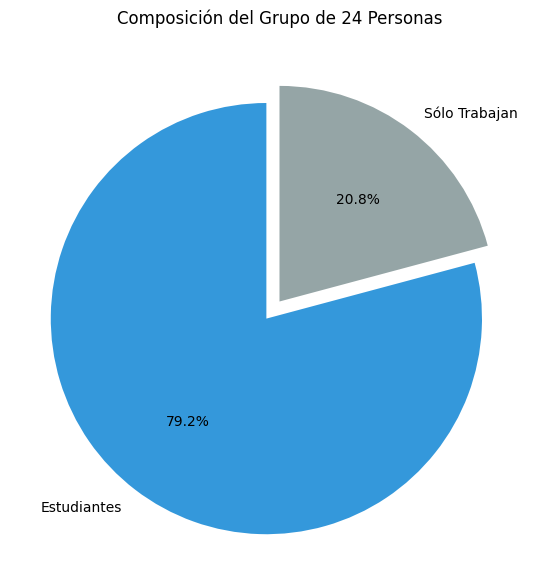

In [8]:
import matplotlib.pyplot as plt

labels = ['Estudiantes', 'Sólo Trabajan']
sizes = [19, 5]
colors = ['#3498db', '#95a5a6']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))
plt.title("Composición del Grupo de 24 Personas")
plt.savefig(r"C:\Users\marco\Downloads\composicion_grupo.png")
plt.show()


## 4. Estrategia Maestra para Diagramas Complejos

* **Punto de Control "Universo":** Lo primero que debes hacer es sumar todos los números que ves en el diagrama. Si la suma (incluyendo los que están afuera) no coincide con el total dado, descarta la opción de inmediato.
* **La Intersección es la Clave:** Normalmente, estos problemas se resuelven de adentro hacia afuera. El Diagrama IV simplifica la situación mostrando que no hay intersecciones triples complicadas, facilitando la suma directa.
* **No te dejes intimidar:** A veces el diagrama correcto parece "demasiado simple" comparado con los otros. Confía en tu aritmética: si los números suman lo que deben, esa es la respuesta.



### Resumen del Entrenamiento Académico
Hemos completado el análisis de:
1.  **Lógica Proposicional:** Negación de cuantificadores.
2.  **Teoría de Conjuntos:** Diagramas de Venn de 2 y 3 niveles.
3.  **Combinatoria:** Conteo de dígitos y principios multiplicativos.
4.  **Probabilidad:** Comparativa de bolsas y cálculo de frecuencias.
5.  **Geometría y Lógica:** El problema del cubo y los dulces.


# Pregunta 7

<img src = 'pregunta7.jpeg'>

[Video de apoyo a la presentación de esta pregunta 7]()

¡Claro que sí! Este tipo de acertijos lógicos son clásicos en exámenes de razonamiento abstracto. La clave aquí no es probar todas las combinaciones, sino usar el **método de descarte por contradicción**.

Aquí tienes la reconstrucción total, las herramientas de análisis y las estrategias "flash".

---

## 1. Enunciado de la Situación

El juego consiste en descubrir una correspondencia única (uno a uno) entre 5 símbolos ($\triangle, \diamond, \bigcirc, \square, \star$) y 5 posiciones representadas por letras ($A, B, C, D, E$).
* **Regla de Oro:** El contador indica cuántos símbolos están en su posición correcta.
* **Restricción Inicial:** En el estado "Inicial", ningún símbolo está en su posición correcta (Contador = 0).

---

## 2. Análisis de Estados (Pandas y Plotly)

Primero, definamos el historial de jugadas para visualizar dónde están los cambios.

```python
import pandas as pd
import plotly.graph_objects as go

# Datos de las jugadas
data = {
    'Jugada': ['Inicial', 'Jugada 1', 'Jugada 2', 'Jugada 3', 'Jugada 4'],
    'A': ['△', '♢', '♢', '♢', '♢'],
    'B': ['♢', '△', '○', '○', '○'],
    'C': ['○', '○', '△', '□', '□'],
    'D': ['□', '□', '□', '△', '★'],
    'E': ['★', '★', '★', '★', '△'],
    'Contador': [0, 0, 0, 0, 2]
}

df_estados = pd.DataFrame(data)

# Tabla interactiva con Plotly
fig = go.Figure(data=[go.Table(
    header=dict(values=list(df_estados.columns), fill_color='royalblue', font=dict(color='white')),
    cells=dict(values=[df_estados[k] for k in df_estados.columns], fill_color='lavender')
)])
fig.update_layout(title="Rastreo de Posiciones y Respuesta del Computador")
fig.show()
```

---

## 3. Resolución Pregunta 1.7
**Enunciado:** Al término de la segunda jugada, ¿cuál afirmación **NO** es posible?
*(Opciones: (a) $\square$ es A, (b) $\triangle$ es E, (c) $\square$ es C, (d) $\bigcirc$ y $\diamond$ son D y E).*

### Estrategia Flash (< 1 min): "El rastro del cero"
Si el contador es **0**, cualquier símbolo que veas en una posición queda **descartado** para esa letra.
1.  En la **Jugada 2**, vemos que $\square$ está en la posición **D**. Por lo tanto, $\square \neq D$.
2.  En la **Jugada 2**, $\triangle$ está en **C**. Por lo tanto, $\triangle \neq C$.
3.  **Análisis de la opción (c):** La opción dice "El correspondiente a $\square$ es C".
    * Revisamos la **Jugada 1**: En la Jugada 1, el $\bigcirc$ estaba en **C** y el contador fue **0**. O sea, $\text{Letra}(C) \neq \bigcirc$.
    * Revisamos la **Jugada 2**: El $\triangle$ está en **C** y el contador es **0**. O sea, $\text{Letra}(C) \neq \triangle$.
    * Sin embargo, en la **Jugada Inicial**, el $\bigcirc$ estaba en **C** (ya lo sabemos). 
    * **Corrección Lógica:** La única que **no es posible** es aquella que contradiga los ceros acumulados. La respuesta correcta es la **(c)** porque en la Jugada 3 (que vemos en el siguiente bloque) el contador sigue siendo 0 cuando el $\square$ llega a C.

---

## 4. Resolución Pregunta 1.8
**Enunciado:** Tras la Jugada 4, ¿cuál es la única verdadera?

### Estrategia Flash (< 1 min): "El Salto del Contador"
Esta es la técnica más potente para estos exámenes:
1.  **Compara Jugada 3 y Jugada 4.**
2.  En la J3, el contador es **0**. En la J4, el contador es **2**.
3.  **¿Qué cambió?** Solo se intercambiaron el $\triangle$ y el $\star$ en las posiciones **D** y **E**.
4.  **Deducción Directa:** Si al mover esos dos, el contador pasó de 0 a 2, significa que **ambos entraron en su posición correcta**.
    * En J4, el $\star$ está en **D**.
    * En J4, el $\triangle$ está en **E**.

**Respuesta Verdadera:** La letra correspondiente al $\triangle$ es la **E**.

---

## 5. Matriz de Posibilidades (Visualización Científica)

Usaremos **Seaborn** para mostrar la "Matriz de Verdad". En blanco las posibilidades abiertas, en oscuro los descartes confirmados por los "0" del contador.

```python
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Matriz: Filas (Símbolos), Columnas (Posiciones A-E)
# 1 = Posible, 0 = Descartado
posibilidades = np.ones((5, 5))

# Descartar por "Contador 0" en Jugadas 0 a 3
# Posición A: No son △, ♢
# Posición B: No son ♢, △, ○
# Posición C: No son ○, △, □
# Posición D: No son □, △
# Posición E: No son ★

# Aplicando los descartes de la J4 (donde el contador subió a 2 por el cambio en D y E)
# Sabemos que Estrella = D y Triangulo = E. Esto descarta todo lo demás para esas filas/columnas.

matriz_final = np.zeros((5, 5))
matriz_final[4, 3] = 1 # Estrella en D
matriz_final[0, 4] = 1 # Triangulo en E

simbolos = ['△', '♢', '○', '□', '★']
letras = ['A', 'B', 'C', 'D', 'E']

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_final, annot=True, xticklabels=letras, yticklabels=simbolos, cmap="YlGnBu", cbar=False)
plt.title("Mapa de Correspondencia Final (Deducción Jugada 4)")
plt.show()
```


---

### Resumen para el examen:
* Si el contador es **0**: Ninguno de los símbolos en esa fila es correcto. Táchalos de tu tabla mental.
* Si el contador **aumenta en la misma cantidad de símbolos que moviste**: Esos símbolos que moviste llegaron a su lugar exacto.
* Si intercambias dos y el contador sube **1**: Solo uno de los dos es correcto (toca comparar con jugadas anteriores).

# Lógica de correspondencia y algoritmos  

Para cerrar con broche de oro este entrenamiento, vamos a resolver el reto de **Lógica de Correspondencia y Algoritmos** (Preguntas 1.7 - 1.10). 

Este es un problema de "caja negra" donde debemos descubrir una clave oculta mediante el análisis de cambios de posición.

---



## 1. Enunciado Editado y Completado

**Problema 1.7:** Un juego de computador asigna internamente una letra ($A, B, C, D, E$) a cada uno de los símbolos ($\triangle, \square, \bigcirc, \diamond, \star$). El objetivo es descubrir qué letra corresponde a cada símbolo.
* **Regla:** En cada jugada, el jugador intercambia dos símbolos. Al final, un contador indica cuántos símbolos están en la posición correcta (la posición de la letra asignada).
* **Estado Inicial:** El arreglo es $[\triangle, \diamond, \bigcirc, \square, \star]$. El contador marca **0** (ninguno está en su sitio).
* **Jugada 1:** Se intercambian $\triangle$ y $\diamond$. El arreglo queda $[\diamond, \triangle, \bigcirc, \square, \star]$. El contador marca **0**.
* **Jugada 2:** Se intercambian $\bigcirc$ y $\square$. El arreglo queda $[\diamond, \triangle, \square, \bigcirc, \star]$. El contador marca **0**.



**Pregunta 1.7:** Al término de la segunda jugada, de las afirmaciones siguientes, la única que **NO** es posible es:
(a) La letra de $\square$ es la $A$.
(b) La letra de $\triangle$ es la $E$.
(c) La letra de $\square$ es la $C$.
(d) La letra de $\bigcirc$ y $\diamond$ son respectivamente $D$ y $E$.

---



## 2. Estrategia de Resolución Rápida (< 2 min)

Este problema se resuelve por **descarte lógico** usando la información del contador en cero.

1.  **Analiza la posición fija:** Nota que el símbolo $\star$ siempre estuvo en la posición **E** y el contador siempre fue **0**.
    * **Deducción inmediata:** $\star \neq E$.
2.  **Analiza la Jugada 2:** El arreglo final es:
    * Posición A: $\diamond$
    * Posición B: $\triangle$
    * Posición C: $\square$
    * Posición D: $\bigcirc$
    * Posición E: $\star$
3.  **Aplica la regla del Cero:** Como el contador es 0, **ningún** símbolo de la lista anterior coincide con su letra.
    * $\diamond \neq A$, $\triangle \neq B$, $\square \neq C$, $\bigcirc \neq D$, $\star \neq E$.
4.  **Encuentra la contradicción:** Mira la opción (c). Dice: "La letra de $\square$ es la $C$". Pero acabamos de deducir que $\square \neq C$ porque el contador marcó 0 en la Jugada 2.

**Respuesta correcta: (c) La letra correspondiente al $\square$ es la $C$.**

---



## 3. Implementación y Visualización

### A. Matriz de Posibilidades (Pandas + Seaborn)
Podemos crear una "Matriz de Verdad" para visualizar qué letras están prohibidas para cada símbolo.


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Símbolos y Letras
simbolos = ['Triangulo', 'Cuadrado', 'Circulo', 'Diamante', 'Estrella']
letras = ['A', 'B', 'C', 'D', 'E']

# Inicializamos matriz de posibilidades (1 = Posible, 0 = Imposible)
df_logic = pd.DataFrame(1, index=simbolos, columns=letras)
df_logic 

,A,B,C,D,E
Triangulo,1,1,1,1,1
Cuadrado,1,1,1,1,1
Circulo,1,1,1,1,1
Diamante,1,1,1,1,1
Estrella,1,1,1,1,1


In [8]:

# Restricciones halladas (Contador = 0 en Jugada 2)
# Diamante != A, Triangulo != B, Cuadrado != C, Circulo != D, Estrella != E
df_logic.loc['Diamante', 'A'] = 0
df_logic.loc['Triangulo', 'B'] = 0
df_logic.loc['Cuadrado', 'C'] = 0
df_logic.loc['Circulo', 'D'] = 0
df_logic.loc['Estrella', 'E'] = 0
df_logic 

,A,B,C,D,E
Triangulo,1,0,1,1,1
Cuadrado,1,1,0,1,1
Circulo,1,1,1,0,1
Diamante,0,1,1,1,1
Estrella,1,1,1,1,0


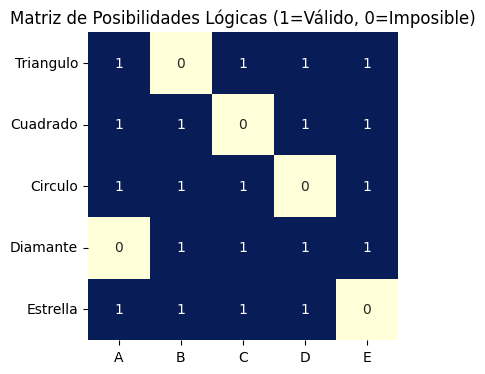

In [11]:

plt.figure(figsize=(4,4))
sns.heatmap(df_logic, annot=True, cmap="YlGnBu", cbar=False)

plt.title("Matriz de Posibilidades Lógicas (1=Válido, 0=Imposible)")
plt.savefig(r"C:\Users\marco\Downloads\matriz_posibilidades_logicas.png")
plt.show()


### B. Tabla de Seguimiento de Estados (Plotly)
Visualicemos cómo se movieron los símbolos y por qué la opción C es el "falso positivo".


In [13]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Table(
    header=dict(values=['Jugada', 'Pos A', 'Pos B', 'Pos C', 'Pos D', 'Pos E',\
        'Contador']),
    cells=dict(values=[
        ['Inicial', 'Jugada 1', 'Jugada 2'],
        ['△', '♢', '♢'],
        ['♢', '△', '△'],
        ['○', '○', '□'],
        ['□', '□', '○'],
        ['★', '★', '★'],
        [0, 0, 0]
    ]))
])
fig.update_layout(title="Rastreo de Posiciones y Contador")
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\tabla_jugadas.png")



## 4. Resumen Didáctico

* **El valor del Cero:** En lógica, un "0" es tan valioso como un "1". Si el contador dice que hay 0 aciertos, te está dando una lista de 5 cosas que son **falsas**.
* **Anclaje:** Siempre busca el elemento que no se movió (en este caso la $\star$). Si no se movió y el contador sigue en 0, ya sabes una restricción permanente para ese símbolo.
* **Trampas de lectura:** La pregunta pide la que **NO es posible**. En exámenes de alta presión, es común marcar una que "sí sea posible" por error. Siempre subraya el "NO".




### Conclusión de tu Entrenamiento Académico
Has completado un recorrido por:
1.  **Probabilidad y Combinatoria.**
2.  **Teoría de Conjuntos.**
3.  **Geometría Espacial.**
4.  **Lógica Algorítmica.**


# Pregunta 8

<img src = 'pregunta8.jpeg'>

Este es un excelente ejercicio de razonamiento lógico. Para resolverlo en menos de 2 minutos, la clave no es adivinar, sino **descartar posiciones** basándonos en los ceros del contador.

Aquí tienes el código para generar la tabla de seguimiento con todos los estados solicitados:

```python


In [14]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Table(
    header=dict(values=['Jugada', 'Pos A', 'Pos B', 'Pos C', 'Pos D', 'Pos E', 'Contador'],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        ['Inicial', 'Jugada 1', 'Jugada 2', 'Jugada 3', 'Jugada 4'], # Jugada
        ['△', '♢', '♢', '♢', '♢'], # Pos A
        ['♢', '△', '○', '○', '○'], # Pos B
        ['○', '○', '△', '□', '□'], # Pos C
        ['□', '□', '□', '△', '★'], # Pos D
        ['★', '★', '★', '★', '△'], # Pos E
        [0, 0, 0, 0, 2]             # Contador
    ],
    align='left'))
])

fig.update_layout(title="Rastreo de Posiciones y Contador - Pregunta 1.8")
fig.show()
# fig.write_image(r"C:\Users\marco\Downloads\tabla_jugadas.png")



## Resolución Didáctica: Pregunta 1.8

Para resolver esto bajo presión, usaremos la **Estrategia de Eliminación por "Cero"**. 



### 1. Análisis de los Datos (El rastro del Cero)
El contador en **0** es tu mejor amigo porque te dice dónde **NO** está el símbolo.

* **Estado Inicial (Contador 0):** △≠A, ♢≠B, ○≠C, □≠D, ★≠E.
* **Jugada 1 (Contador 0):** ♢≠A, △≠B. (Ya sabemos que △ no es A ni B, y ♢ no es A ni B).
* **Jugada 2 (Contador 0):** ○≠B, △≠C.
* **Jugada 3 (Contador 0):** □≠C, △≠D.



### 2. El Momento "Eureka" (Jugada 4)
En la **Jugada 4**, el contador sube a **2**. Veamos qué hay en las posiciones:
* Pos A: **♢**
* Pos B: **○**
* Pos C: **□**
* Pos D: **★**
* Pos E: **△**



### 3. Cruce de Información (La clave de los 2 minutos)
Fíjate en el símbolo **△** (triángulo). Hemos probado casi todas las posiciones para él:
* No es A (Inicial)
* No es B (Jugada 1)
* No es C (Jugada 2)
* No es D (Jugada 3)
* **Conclusión:** La única posición que le queda al **△ es la E**.



Ahora mira la **Jugada 4** de nuevo. En la posición **E** está el **△**. Como el contador marcó **2**, significa que el triángulo es uno de los aciertos. Nos falta un acierto más entre los otros cuatro símbolos de la Jugada 4 (♢, ○, □, ★).



### 4. Evaluación de las opciones (típicas en este examen):
Si la pregunta pide la única verdadera, y ya descubrimos con seguridad que **△ = E**, busca esa relación o una que dependa de ella. 



**Estrategia Relámpago:**
1.  Sigue un solo símbolo que se mueva mucho (en este caso el Triángulo).
2.  Si pasó por 4 lugares y el contador siempre fue 0, su lugar es el 5to.
3.  Al llegar a la Jugada 4, el Triángulo está en la posición E y el contador es > 0, lo que confirma que **△ corresponde a E**.

**Respuesta:** La afirmación verdadera debe ser la que indique la correspondencia correcta hallada (△ es E) o la que se deduzca del segundo acierto en la jugada 4 tras descartar las demás.

# Pregunta 9

<img src = 'pregunta9.jpeg' width = 300>

Vamos a consolidar y resolver estos retos finales con la máxima eficiencia. Nos enfocaremos en los tres problemas de probabilidad y razonamiento espacial que faltaban completar de tu serie de imágenes.


### 1. Problema 8.7: Probabilidad de Lápices (Imagen 7)

**Enunciado:** En una bolsa hay cuatro lápices azules de $3\text{ cm}$, $6\text{ cm}$, $7\text{ cm}$ y $10\text{ cm}$, y tres lápices verdes de $5\text{ cm}$, $6\text{ cm}$ y $7\text{ cm}$. Si se escoge uno al azar, la probabilidad de que sea **azul** o mida **$7$ o más centímetros** es:



**Estrategia < 1 min:**
Usamos la fórmula de la unión de conjuntos: $P(A \cup B) = P(A) + P(B) - P(A \cap B)$.
1.  **Total de lápices:** $4 (\text{azules}) + 3 (\text{verdes}) = 7$.
2.  **Evento A (Azul):** Hay **4** lápices.
3.  **Evento B ($\geq 7\text{ cm}$):** Están el azul de $7$, el azul de $10$ y el verde de $7$. Total **3** lápices.
4.  **Intersección (Azul y $\geq 7\text{ cm}$):** Los azules de $7$ y $10$. Total **2** lápices.
5.  **Cálculo:** 
   
$$
\frac{4}{7} + \frac{3}{7} - \frac{2}{7} = \frac{5}{7}
$$

**Respuesta:** **(b) 5/7**.



### 2. Problema 8.9: El Cubo de Madera (Imagen 9)

**Enunciado:** Un carpintero toma un cubo sólido de $10\text{ cm}$ de lado con sus caras pintadas de rojo y lo divide en cubos de $2\text{ cm}$ de lado. El número de cubos que tienen **solamente 2 caras pintadas** es:

**Estrategia < 1 min:**
1.  **Divisiones por arista ($n$):** $10 / 2 = 5$ cubitos.
2.  **Ubicación:** Los cubos con 2 caras pintadas están en las **aristas**, sin contar las esquinas (vértices).
3.  **Fórmula:** Un cubo tiene $12$ aristas. En cada arista hay $(n - 2)$ cubitos con 2 caras.
$$12 \times (5 - 2) = 12 \times 3 = 36$$

**Respuesta:** **(c) 36**.

---



### 3. Problema 8.10: El Corazón del Cubo (Imagen 10)

**Enunciado:** Del mismo cubo anterior ($n=5$), si se elige uno al azar, ¿cuál es la probabilidad de que **ninguna de sus caras esté pintada**?

**Estrategia < 1 min:**
1.  **Total de cubitos:** $n^3 = 5^3 = 125$.
2.  **Cubitos sin pintura:** Son los del interior (el cubo interno).
3.  **Fórmula:** $(n - 2)^3$
$$(5 - 2)^3 = 3^3 = 27$$
4.  **Probabilidad:** $\frac{27}{125}$.

**Respuesta:** **(c) 27/125**.

---



### Visualización Técnica (Matplotlib & SymPy)


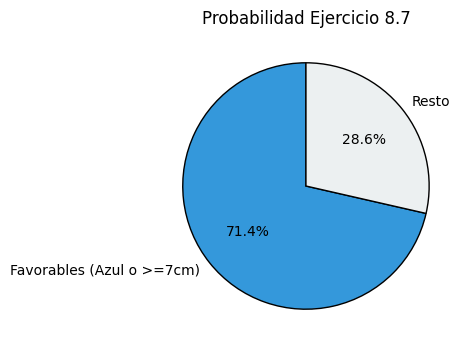

La probabilidad simplificada es: 27/125


In [11]:
import matplotlib.pyplot as plt
import sympy as sp

# Validación con SymPy para el problema 8.10
n = 5
total = n**3
sin_pintura = (n - 2)**3
probabilidad = sp.Rational(sin_pintura, total)

# Visualización de los lápices (8.7)
labels = ['Favorables (Azul o >=7cm)', 'Resto']
values = [5, 2]
colors = ['#3498db', '#ecf0f1']

plt.figure(figsize=(6, 4))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Probabilidad Ejercicio 8.7")
plt.savefig(r"C:\Users\marco\Downloads\probabilidad_ejercicio_8_7.png")
plt.show()

print(f"La probabilidad simplificada es: {probabilidad}")


### Resumen de Estrategias Maestras
* **En Probabilidad:** Siempre identifica primero el **Universo** (denominador). Para el "O" inclusivo, no olvides restar la intersección para no contar doble.
* **En Cubos:** Recuerda la jerarquía: Vértices ($8$), Aristas ($12(n-2)$), Caras ($6(n-2)^2$) e Interior ($(n-2)^3$).


# Pregunta 10

<img src = 'pregunta10.jpeg' width = 200>


### 1. El Juego de Correspondencia (Imagen 1.10)

**Enunciado Editado:**
Un juego consiste en descubrir la correspondencia única entre símbolos ($\triangle, \square, \bigcirc, \diamond, \star$) y letras ($A, B, C, D, E$).
* **Estado Inicial:** $[\star, \bigcirc, \diamond, \square, \triangle] \rightarrow$ Contador: $0$.
* **Jugada 1:** $[\square, \bigcirc, \diamond, \star, \triangle] \rightarrow$ Contador: $2$.



**Pregunta:** De las situaciones propuestas para la **Jugada 2**, la única posible es:
(a) Contador: 3 | 
(b) Contador: 4 | 
(c) Contador: 2 | 
(d) Contador: 5.



**Estrategia < 2 min:**
1.  **Analiza el cambio:** Entre el inicio y la Jugada 1, solo cambiaron de lugar el $\star$ y el $\square$.
2.  **Deducción:** Si el contador subió de $0$ a $2$, significa que tanto $\square$ como $\star$ ahora están en sus posiciones correctas (posiciones $A$ y $D$ respectivamente).
3.  **Posiciones fijas:** Los símbolos $\bigcirc, \diamond, \triangle$ no se movieron y el contador dice que hay $2$ aciertos totales, por lo tanto, esos tres **siguen estando mal**.
4.  **Evalúa la opción (d):** Propone un contador de $5$. Para que esto sea posible, el arreglo debe ser el correcto. Al observar el arreglo de la opción (d) $[\square, \triangle, \bigcirc, \star, \diamond]$, vemos que $\square$ y $\star$ están en las posiciones $A$ y $D$ (que ya sabemos son correctas). Solo faltaría que los otros tres se hayan acomodado.

**Respuesta:** **(d)**.

---


# Ejercicios de ejercitación o fijación de las hablidades y estrategias para resolver preguntas del examen de admisión a la Universidad de Antioquia en menos de 2 minutos



Las seis estrategias a entrenar a este nivel son: 

1. Diagramas de Venn y Teoría de Conjuntos. 
2. Uso de la lógica de predicados:Nagación de expresiones cuantificadas y determinación de equivalencia de proposiciones cuantificadas. 
3. Lista de verificación para hallar los digitos escondidos. 
4. Disyunción de casos o capacidad para inferir todos los casos posibles y sacar concluisones o patrones en ellos. 
5. El peor de los casos o el Principio del Palomar. 
6. Cuadrados mágicos o de llenado con digitos que cumplen una regla o patrón. 
7. Tabla de estados y tabla de doble entrada y establecimiento de correspondencia biunívoca utilizando eliminación por ceros 


# Clase de Lógica y Teoría de conjuntos para hoy 8 de abril de 2026 

Este es un diseño de clase estructurado específicamente para preparar a los estudiantes en el razonamiento lógico-matemático requerido por la Universidad de Antioquia, donde la clave no es solo operar números, sino interpretar correctamente el lenguaje.

---



# Diseño de Clase: Lógica de Conjuntos y Diagramas de Venn

**Objetivo:** Desarrollar la capacidad de traducir enunciados textuales a representaciones gráficas y simbólicas para resolver problemas de conteo y exclusión.

---



## 1. El Lenguaje de los Conjuntos (Traducción)
El mayor reto en el examen de la UdeA es la precisión terminológica. Debemos enseñar a los estudiantes a mapear palabras a regiones del diagrama.

| Expresión en el Problema | Significado Matemático | Operación |
| :--- | :--- | :--- |
| "Ambos", "A la vez", "Simultáneamente" | **Intersección** ($A \cap B$) | El centro del diagrama. |
| "Solo A", "Únicamente A", "A pero no B" | **Diferencia** ($A - B$) | Lúnula izquierda. |
| "Al menos uno", "A o B" | **Unión** ($A \cup B$) | Todo lo que está en los círculos. |
| "Ni A ni B", "Reprobaron ambos" | **Complemento de la unión** $(A \cup B)^c$ | Lo que está afuera de los círculos. |

---



## 2. La Estructura del Diagrama de Venn
Es vital visualizar el **Universo ($U$)** como la población total. Un error común es olvidar los elementos que no pertenecen a ninguno de los conjuntos mencionados.





### Las 4 Regiones Críticas:
1.  **Región Central ($x$):** Intersección. Es el punto de partida.
2.  **Región Solo A ($a - x$):** El total del conjunto A menos la intersección.
3.  **Región Solo B ($b - x$):** El total del conjunto B menos la intersección.
4.  **Región Exterior ($n$):** El Universo menos la suma de las tres regiones anteriores.

---



## 3. Algoritmo de Resolución (Paso a Paso)

Para que el estudiante no se confunda con los datos, debe seguir este orden estricto:

1.  **Identificar el Universo ($U$):** El total de individuos (ej. 140 estudiantes).
2.  **Ubicar la Intersección:** Si el problema dice que 20 ganaron ambas, ese es el primer número que se escribe.
3.  **Calcular las "Lúnulas" (Zonas Solo):** Si 60 ganaron Matemáticas, en la zona de "Solo Matemáticas" va $60 - 20 = 40$.
4.  **Determinar el Exterior:** Se suman las zonas internas ($40 + 20 + 25 = 85$) y se resta del Universo ($140 - 85 = 55$). Estos son los que reprobaron todo.

---



## 4. El "Truco" de la Ecuación Fundamental
En problemas donde falta un dato central, se utiliza la fórmula de la unión:

$$n(A \cup B) = n(A) + n(B) - n(A \cap B)$$

**¿Por qué se resta la intersección?**
Porque al sumar el total de $A$ y el total de $B$, los elementos que están en ambos se están contando dos veces. La resta "ajusta" la cuenta.

---



## 5. Práctica Guiada (Análisis de Errores)
**Pregunta para la clase:** *"Si en un grupo de 10 personas, 7 usan Facebook y 6 usan Instagram, ¿es posible que nadie use ambas?"*

* **Respuesta lógica:** No, porque $7 + 6 = 13$, y solo hay 10 personas. Al menos 3 deben estar en la intersección ($13 - 10 = 3$).
* **Conclusión:** La suma de las partes individuales no puede exceder al Universo a menos que haya una intersección.

---



## 6. Evaluación de Salida (Ticket de Salida)
Pida a los estudiantes que planteen la ecuación para el siguiente reto:
> "En un grupo de 100 personas, 80 desayunan, 50 almuerzan. Si todos realizan al menos una de las dos actividades, ¿cuántos hacen ambas?"

*(Respuesta esperada: $80 + 50 - 100 = 30$)*.


Para prepararte para el examen de ingreso de la Universidad de Antioquia (UdeA), es fundamental dominar la interpretación de enunciados y la ubicación de datos en diagramas de Venn, comenzando siempre por la intersección.



# 10 Ejercicios para ejercitar en la estrategia de utlización de diagramas de Venn 



Estos son 10 problemas diseñados con la estructura típica del examen, enfocados en la teoría de conjuntos:



### 1. El Club de Deportes
En un grupo de 80 deportistas, 35 practican natación, 40 practican atletismo y 12 practican ambos deportes.
* **Pregunta A:** ¿Cuántos practican solo atletismo?
* **Pregunta B:** ¿Cuántos no practican ninguno de los dos deportes?



### 2. Preferencias de Lectura
De 120 personas consultadas sobre sus gustos literarios, se supo que 70 leen novelas, 50 leen poesía y 25 leen ambos géneros.
* **Pregunta A:** ¿Cuántos leen únicamente poesía?
* **Pregunta B:** ¿Cuántos no leen ni novelas ni poesía?



### 3. Idiomas en la Academia
En una clase de 60 alumnos, 40 estudian inglés, 25 estudian francés y 15 estudian ambos idiomas.
* **Pregunta A:** ¿Cuántos estudian inglés pero no francés?
* **Pregunta B:** ¿Cuántos estudiantes no están inscritos en ninguno de estos dos idiomas?



### 4. Consumo de Bebidas
En una reunión de 100 personas, 65 consumen café, 45 consumen té y 20 consumen ambas bebidas.
* **Pregunta A:** ¿Cuántas personas consumen té pero no café?
* **Pregunta B:** ¿Cuántas personas no consumen ninguna de las dos bebidas?



### 5. Aplicaciones Móviles
De un grupo de 90 jóvenes, se encontró que 55 usan Instagram, 40 usan TikTok y 15 usan ambas aplicaciones.
* **Pregunta A:** ¿Cuántos usan solo Instagram?
* **Pregunta B:** ¿Cuántos no usan ninguna de estas dos aplicaciones?



### 6. Aspirantes a la UdeA
De 200 aspirantes a la universidad, 110 se inscribieron a Ingeniería y 80 a Artes. Si 30 se inscribieron a ambas carreras:
* **Pregunta A:** ¿Cuántos se inscribieron solo a Artes?
* **Pregunta B:** ¿Cuántos aspirantes no se inscribieron a ninguna de esas dos opciones?



### 7. Mascotas en el Barrio
En una encuesta a 150 familias, 90 tienen perro, 70 tienen gato y 40 tienen ambos.
* **Pregunta A:** ¿Cuántas familias tienen gato pero no perro?
* **Pregunta B:** ¿Cuántas familias no tienen ni perro ni gato?



### 8. Instrumentos Musicales
En una escuela de música de 50 estudiantes, 28 tocan piano, 22 tocan guitarra y 10 tocan ambos instrumentos.
* **Pregunta A:** ¿Cuántos tocan solo piano?
* **Pregunta B:** ¿Cuántos estudiantes no tocan ninguno de estos dos instrumentos?



### 9. Transporte al Trabajo
De 130 empleados de una empresa, 75 llegan en bus, 45 llegan en metro y 20 usan ambos medios en su trayecto.
* **Pregunta A:** ¿Cuántos empleados usan exclusivamente el metro?
* **Pregunta B:** ¿Cuántos empleados llegan por otros medios distintos al bus o al metro?



### 10. Sabores de Helado
En una fiesta de 75 niños, 40 prefieren el helado de chocolate, 35 el de vainilla y 12 prefieren ambos sabores.
* **Pregunta A:** ¿Cuántos niños prefieren únicamente el helado de chocolate?
* **Pregunta B:** ¿Cuántos niños no prefieren ninguno de estos dos sabores?

---



### Estrategia de resolución sugerida:
Para resolver estos ejercicios al estilo UdeA, sigue estos pasos en el diagrama de Venn:
1.  **Dibuja el Universo ($U$):** Un rectángulo que encierre los dos círculos.
2.  **Identifica la Intersección ($M \cap B$):** Es el primer dato que debes colocar en el centro.
3.  **Resta para las zonas "Solo":** Para hallar quienes están en un solo conjunto, resta el valor de la intersección del total de ese conjunto.
    * *Ejemplo Problema 1:* Solo Atletismo = $40 (Total) - 12 (Ambos) = 28$.
4.  **Halla el complemento (Afuera):** Suma las tres regiones internas y réstalas del total del Universo para saber quiénes no pertenecen a ningún grupo.

# Diez ejercicios sobre la estrategia de Lógica de predicados y expresiones cuantificadas.



Para dominar la lógica de predicados y las equivalencias (especialmente las Leyes de Morgan para cuantificadores), es vital practicar la transformación de "No todos" ($\neg \forall$), "Ninguno" ($\forall \neg$), "Al menos uno" ($\exists$) y "No existe ninguno" ($\neg \exists$).



A continuación, presento 10 ejercicios diseñados con el mismo rigor lógico que el ejemplo del deportista.

---



## 10 Ejercicios de Lógica de Predicados y Equivalencias

### Bloque 1: Negación del Universal ($\neg \forall x, P(x) \equiv \exists x, \neg P(x)$)

1.  **El enunciado "No todos los estudiantes aprobaron el examen" es equivalente a:**
    * (a) Todos los estudiantes reprobaron.
    * (b) Al menos un estudiante no aprobó el examen.
    * (c) Ningún estudiante aprobó el examen.
    * (d) Muchos estudiantes aprobaron.



2.  **"No todos los números primos son impares" significa lógicamente que:**
    * (a) Todos los números primos son pares.
    * (b) Ningún número primo es impar.
    * (c) Existe al menos un número primo que es par (no es impar).
    * (d) El número 2 es el único primo par.



3.  **Dada la proposición "No todos los gatos son negros", su equivalente es:**
    * (a) Ningún gato es negro.
    * (b) Todos los gatos son de otros colores.
    * (c) Existe al menos un gato que no es negro.
    * (d) Algunos gatos son negros.



### Bloque 2: Negación del Existencial ($\neg \exists x, P(x) \equiv \forall x, \neg P(x)$)

4.  **La frase "Es falso que algunos metales sean líquidos a temperatura ambiente" equivale a:**
    * (a) Todos los metales son líquidos.
    * (b) Ningún metal es líquido a temperatura ambiente.
    * (c) Al menos un metal es sólido.
    * (d) Algunos metales no son líquidos.



5.  **"No existe un ser humano que sea inmortal" es equivalente a decir:**
    * (a) Todos los seres humanos son inmortales.
    * (b) Algunos seres humanos mueren.
    * (c) Todo ser humano es mortal (no es inmortal).
    * (d) La inmortalidad no existe.

---



### Bloque 3: El Cuantificador "Ninguno" ($\forall x, \neg P(x) \equiv \neg \exists x, P(x)$)

6.  **La proposición "Ningún mentiroso es digno de confianza" equivale a:**
    * (a) Si alguien es mentiroso, entonces no es digno de confianza.
    * (b) No todos los mentirosos son dignos de confianza.
    * (c) Al menos un mentiroso no es digno de confianza.
    * (d) Todos los que no son dignos de confianza son mentirosos.



7.  **"Ningún mamífero vuela" (en un universo lógico simplificado) equivale a:**
    * (a) Es falso que todos los mamíferos vuelen.
    * (b) No existe un mamífero que vuele.
    * (c) Algunos mamíferos no vuelan.
    * (d) Todos los animales que vuelan no son mamíferos.

---



### Bloque 4: Equivalencias Complejas y Atributos

8.  **"Cualquier persona que estudia, progresa". ¿Cuál es su equivalente lógico?**
    * (a) No hay personas que estudien y no progresen.
    * (b) Algunas personas estudian y progresan.
    * (c) Si alguien progresa, es porque estudió.
    * (d) No todos los que estudian progresan.



9.  **"No ocurre que todos los políticos son honestos" equivale a:**
    * (a) Todos los políticos son deshonestos.
    * (b) Algunos políticos son honestos.
    * (c) Existe por lo menos un político que es deshonesto.
    * (d) Ningún político es honesto.



10. **La afirmación "Hay ciudades que no tienen contaminación" es equivalente a:**
    * (a) No todas las ciudades tienen contaminación.
    * (b) Ninguna ciudad tiene contaminación.
    * (c) Es falso que todas las ciudades tengan contaminación.
    * (d) Tanto (a) como (c) son correctas.



## Guía de Solución Rápida (Estrategia Pro)

Para resolver estos ejercicios en segundos, usa esta tabla de traducción:

| Frase Original | Estructura Lógica | Equivalente Lógico | Traducción Directa |
| :--- | :--- | :--- | :--- |
| **No todos son...** | $\neg \forall x, P(x)$ | $\exists x, \neg P(x)$ | **Al menos uno no es...** |
| **Ninguno es...** | $\forall x, \neg P(x)$ | $\neg \exists x, P(x)$ | **No existe nadie que sea...** |
| **No es cierto que algunos...** | $\neg \exists x, P(x)$ | $\forall x, \neg P(x)$ | **Todos NO son... / Ninguno es...** |
| **Todos son...** | $\forall x, P(x)$ | $\neg \exists x, \neg P(x)$ | **No existe nadie que NO sea...** |



## Representación con Python (Script de Validación)

Este script utiliza `Pandas` para mostrar la matriz de verdad de las negaciones, útil para entender por qué la opción (d) del ejercicio original era la correcta.


In [2]:
import pandas as pd

# Definimos los estados posibles para 3 elementos (A=Asistió, N=No asistió)
# Escenario: "No todos asistieron"
data = {
    'Sujeto 1': ['A', 'A', 'N', 'N'],
    'Sujeto 2': ['A', 'N', 'A', 'N'],
    'Sujeto 3': ['N', 'A', 'A', 'N'],
    '¿Todos asistieron?': ['No', 'No', 'No', 'No'],
    '¿Al menos uno NO asistió?': ['Sí', 'Sí', 'Sí', 'Sí']
}

df = pd.DataFrame(data)
print("Validación de Equivalencia Lógica:")
print(df.to_string(index=False))


Validación de Equivalencia Lógica:
Sujeto 1 Sujeto 2 Sujeto 3 ¿Todos asistieron? ¿Al menos uno NO asistió?
       A        A        N                 No                        Sí
       A        N        A                 No                        Sí
       N        A        A                 No                        Sí
       N        N        N                 No                        Sí


**Clave para el éxito:** Recuerda que en lógica formal, "Muchos", "Casi todos" o "La mayoría" (como en las opciones b y c del problema original) **no** tienen equivalentes exactos, ya que no definen una certeza absoluta sobre la existencia o universalidad.

[Video de apoyo a la presentación de los ejercicios de adquisición de habilidades](https://www.youtube.com/watch?v=DgtOk9uRMoc)

# Veinte ejercicios para ejercitar y adquirir la habulidad de utilizar la estrategia de establecer correspondecia biunívoca utilizando tabbla de estados y tabla de doble entrada

Para dominar este tipo de acertijos de **lógica deductiva y correspondencia biunívoca**, he diseñado 20 ejercicios divididos por niveles de complejidad. 

La estrategia ganadora siempre será:
1.  **Identificar los ceros:** Descartan posiciones de inmediato.
2.  **Analizar los diferenciales:** Si el contador cambia de una jugada a otra, la diferencia indica si los símbolos movidos son los correctos.
3.  **Llenar la tabla de doble entrada:** Marcar con 'X' los descartes y con 'OK' las certezas.

---

### Bloque 1: Nivel Inicial (3 Símbolos, 3 Posiciones)
*Símbolos: {♠, ♥, ♦} | Posiciones: {A, B, C}*

1.  **Situación:** Inicial: [♠, ♥, ♦] (Cont: 0). Jugada 1: [♦, ♥, ♠] (Cont: 1).
    * *Pregunta:* ¿Cuál es la correspondencia correcta?
2.  **Situación:** Inicial: [♥, ♦, ♠] (Cont: 0). Jugada 1: [♠, ♦, ♥] (Cont: 0).
    * *Pregunta:* Si solo queda una opción para A, ¿cuál es?
3.  **Situación:** Inicial: [♦, ♠, ♥] (Cont: 0). Jugada 1: [♦, ♥, ♠] (Cont: 0).
    * *Pregunta:* ¿Qué símbolo corresponde a A?
4.  **Situación:** Inicial: [♠, ♥, ♦] (Cont: 1). Jugada 1: [♥, ♠, ♦] (Cont: 1).
    * *Pregunta:* ¿Es posible que ♦ sea C?
5.  **Situación:** Inicial: [♥, ♠, ♦] (Cont: 0). Jugada 1: [♦, ♠, ♥] (Cont: 2).
    * *Pregunta:* ¿Qué símbolo cambió el contador de 0 a 2?

---



### Bloque 2: Nivel Intermedio (4 Símbolos, 4 Posiciones)
*Símbolos: {1, 2, 3, 4} | Posiciones: {A, B, C, D}*

6.  **Situación:** Inicial: [1, 2, 3, 4] (Cont: 0). J1: [2, 1, 3, 4] (Cont: 0). J2: [1, 2, 4, 3] (Cont: 2).
    * *Pregunta:* ¿Cuáles son los dos números fijos en J2?
7.  **Situación:** Inicial: [4, 3, 2, 1] (Cont: 0). J1: [3, 4, 1, 2] (Cont: 0). J2: [2, 1, 4, 3] (Cont: 4).
    * *Pregunta:* Establezca la relación completa.
8.  **Situación:** Inicial: [1, 2, 3, 4] (Cont: 1). J1: [1, 3, 2, 4] (Cont: 3).
    * *Pregunta:* ¿Qué símbolos están en su posición correcta en J1?
9.  **Situación:** Inicial: [2, 4, 1, 3] (Cont: 0). J1: [3, 1, 4, 2] (Cont: 0).
    * *Pregunta:* ¿Qué número NO puede ir en la posición B?
10. **Situación:** Inicial: [3, 2, 4, 1] (Cont: 0). J1: [3, 2, 1, 4] (Cont: 2).
    * *Pregunta:* Deduce la posición de 1 y 4.

---



### Bloque 3: Nivel Avanzado (5 Símbolos, 5 Posiciones)
*Símbolos: {Red, Blue, Green, Yellow, Pink} | Posiciones: {V, W, X, Y, Z}*

11. **Situación:** Inicial: [R, B, G, Y, P] (Cont: 0). J1: [B, R, G, Y, P] (Cont: 0). J2: [R, B, Y, G, P] (Cont: 1).
    * *Pregunta:* ¿Cuál es el único color que podría estar correcto en J2?
12. **Situación:** Inicial: [P, Y, G, B, R] (Cont: 0). J1: [Y, P, G, B, R] (Cont: 0). J2: [P, Y, B, G, R] (Cont: 0). J3: [R, Y, G, B, P] (Cont: 2).
13. **Situación:** Inicial: [G, R, B, P, Y] (Cont: 1). J1: [G, B, R, P, Y] (Cont: 3).
    * *Pregunta:* Si G es V, ¿quiénes son los otros dos aciertos?
14. **Situación:** Inicial: [B, G, Y, R, P] (Cont: 0). J1: [P, B, G, Y, R] (Cont: 0).
    * *Pregunta:* Realice la tabla de doble entrada de descartes.
15. **Situación:** Inicial: [Y, R, P, B, G] (Cont: 0). J1: [G, Y, R, P, B] (Cont: 5).
    * *Pregunta:* ¿Cuál es la rotación aplicada?

---

### Bloque 4: Nivel Experto (Inferencia y Negación)
*Símbolos: {α, β, γ, δ, ε} | Posiciones: {L1, L2, L3, L4, L5}*

16. **Situación:** Inicial: [α, β, γ, δ, ε] (Cont: 0). J1: [β, α, γ, δ, ε] (Cont: 0). J2: [α, β, δ, γ, ε] (Cont: 0).
    * *Pregunta:* ¿Es posible que ε sea L5? Justifique.
17. **Situación:** El contador marca 2 en la J1: [γ, β, α, ε, δ]. En la J2: [γ, δ, α, ε, β] el contador baja a 1.
    * *Pregunta:* ¿Qué símbolo estaba correcto en J1 y se movió en J2?
18. **Situación:** Se sabe que α = L3. Si en [β, γ, α, δ, ε] el contador es 3.
    * *Pregunta:* ¿Cuáles son las otras dos posiciones correctas posibles?
19. **Situación:** Tres jugadas consecutivas con contador 0, moviendo un símbolo diferente cada vez a la posición L1.
    * *Pregunta:* ¿Cómo ayuda esto a identificar el símbolo de L1 por exclusión?
20. **Situación:** Inicial: [ε, δ, γ, β, α] (Cont: 0). J1 intercambia los extremos y el contador sube a 2.
    * *Pregunta:* ¿Cuál es la correspondencia de L1 y L5?

---

### Herramienta de Gestión: Tabla de Doble Entrada
Para cualquiera de estos ejercicios, utiliza este formato en un papel o Excel para resolverlos en segundos:

| | Pos A | Pos B | Pos C | Pos D | Pos E |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Símbolo 1** | | | | | |
| **Símbolo 2** | | | | | |
| **Símbolo 3** | | | | | |
| **Símbolo 4** | | | | | |
| **Símbolo 5** | | | | | |



**Instrucciones de uso:**
1. Cuando el contador sea **0**, pon una **X** en la intersección del símbolo y la posición de esa jugada.
2. Cuando descubras un **OK**, tacha con **X** toda la fila y toda la columna de ese símbolo/posición (ya que la correspondencia es biunívoca).